# 리포트 8-3 — 마이크로도플러: 무엇이 무늬를 정하나

> **8 권은 다섯 편이다** — [08_1 시나리오](08_1_scene.ipynb) · [08_2 세 엔진과 거리](08_2_engines.ipynb) · [08_3 무늬를 정하는 것](08_3_pattern.ipynb) · [08_4 무엇을 잴 수 있나](08_4_sampling.ipynb) · [08_5 바이스태틱](08_5_bistatic.ipynb)

> **회전수·가림·산포 세 가지가 무늬를 정한다.** 각각을 갈라서 얼마나 바꾸는지 잰다.

엔진 비교의 **결론**은 [08_2](08_2_engines.ipynb) 가 요약하고, 그 **근거 절은 이 편 절 3**(«두 엔진이 갈린다») 에 있다. 앞머리 네 그림은 **표적 쪽 요인**을 다룬다.

⭐ **이 편이 쓰는 팔 셋** — **S** = Sionna PathSolver · **B** = Ours (SBR+PO, 기본)(광선 격자로 가림을 푼다) · **P** = Ours, nothing blocked (control)(점구름 면적분 · 광선 격자를 안 쓴다). 절마다 어느 팔이 재었는지를 이 세 이름으로 적는다.

⭐ **이 편의 맵은 얼린 광선 격자 위에 서 있다**(f1 · f4 · f7 · f11). 자를 자세마다 다시 놓으면 자의 움직임이 표적의 운동으로 기록되는데, 이 편의 맵은 판 한 장을 모든 자세가 함께 쓰는 계산으로 다시 났다. 전후 비교(레벨 · 변조 깊이 · 대역밖 전력 · 가산성)는 [08_2 «광선 격자를 어디에 매나»](08_2_engines.ipynb) 가, 기전과 대가는 [리포트 5 «우리 커널 — 무엇이고, 무엇이 아닌가»](05_kernel.ipynb) 가 낸다. ⚠ **f3 만 예외다** — 그 그림의 밴드별 깊이는 옛 판에서 잰 값이라 절대 dB 를 인용하지 마라(8-4 의 «그림별 데이터 이력» 참조).

⭐ 본문 숫자는 계산 결과 JSON(원장)에서 주입된다 — 원장이 다시 계산되면 `python src/make_report08_microdoppler.py` 한 번으로 본문 숫자가 따라 바뀐다. 원장이 없는 자리는 «원장 없음» 이라고 적고 그 숫자를 비율·헤드라인에서 뺀다.


## 회전수가 같으면 무늬가 시간에 안 변한다

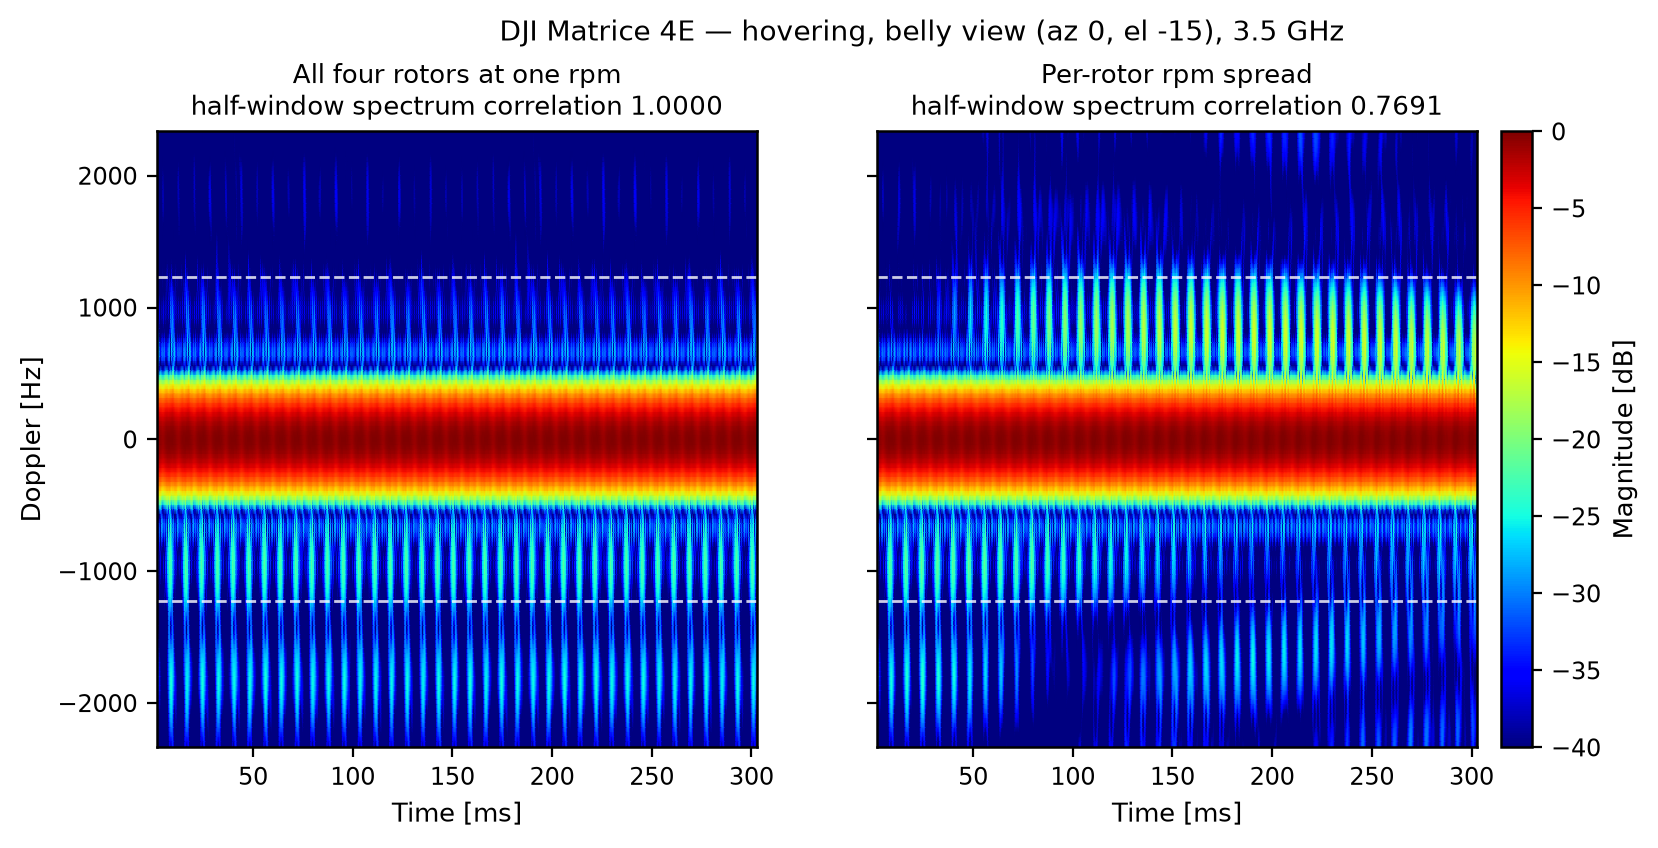

왼쪽은 네 로터를 **같은 회전수**로 돌린 것이다. 줄무늬가 시간축 내내 같은 자리에 선다 — 창을 반으로 갈라 두 스펙트럼의 상관을 재면 **1.0000** 다. 우연이 아니라 원리다: 네 로터가 같은 속도로 돌면 신호가 완전한 주기함수가 되고, 주기함수의 스펙트로그램은 창 내내 자기 모습을 지킨다.

오른쪽은 로터마다 회전수를 **±0.22 %** 흩뜨린 것이다 — 추측이 아니라 **PX4 SITL**(소프트웨어 인더루프 = 시뮬) 로그에서 모터 간 0.07~0.29 % 를 재서 고른 중간값이다. ⚠**실기 텔레메트리가 아니다** — 아래 «로터 산포 프리셋 비교» 가 실기 비행로그 세 종으로 이 값이 야외 호버를 한 자릿수 과소평가함을 보인다. 이 그림에서 ±0.22 % 는 «산포가 무늬를 시간에 변하게 한다» 를 보이는 **하한 예시**다. 상관이 **0.7691** 로 내려가고(낙차 0.2308) 줄이 숨쉬듯 흔들린다. ⭐그 내려감이 «시간에 따라 변한다» 의 정량이다.

⭐ **두 팔이 같은 낙차를 낸다.** 위 두 수는 **B 팔**(SBR)이고, 같은 칸의 **P 팔**(순수 PO · 가림 없음 · 광선 격자 안 씀)은 1.0000 에서 0.7669 로 내려간다. 가림을 켠 팔과 아예 안 켠 팔이 같은 답을 내므로, 이 축의 원인은 **rpm 산포** 하나다(`outputs/report15b_microdoppler.json : cells.matrice4e/belly.arms.{C_po_locked, D_po_spread}`).


## 동체가 막으면 무엇이 달라지나

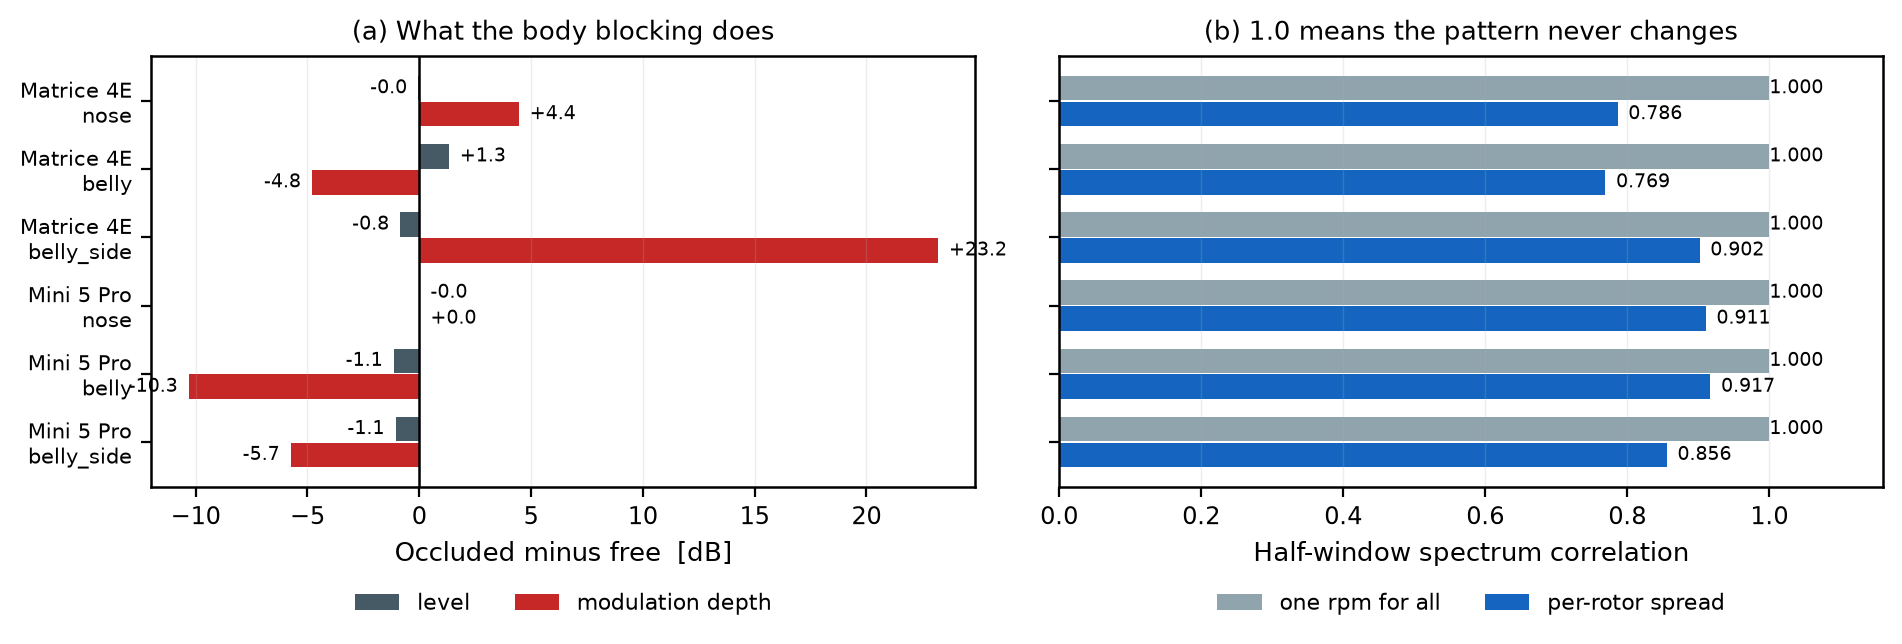

가림 단일축(F↔G)의 실측이다 — 둘 다 **B 팔**(SBR)이고, 광선 엔진·재질·기하·운동학·**광선 격자**까지 같고 오직 «동체가 막느냐» 만 다르다. 레벨은 +1.31 dB, 변조 깊이는 -4.79 dB 움직인다.

⭐ **이 축은 B 팔에서만 선다** — P 팔(순수 PO)은 모든 면이 항상 기여하는 설계라 «막느냐» 라는 스위치가 그 팔의 밖에 있다. 그래서 이 그림에는 P 대조가 없고, 그 사실이 이 축의 한계다.

⚠ 합이 코히런트라 **가림이 레벨을 올릴 수도 있다** — 항이 줄어도 남은 항끼리 상쇄가 덜 되면 그렇다. 부호를 물리로 단정하지 말 것. 여섯 칸에서 부호가 실제로 갈린다 — 칸별 부호표는 절 5 가 낸다.


## 블레이드는 강하고 동체가 덮는다

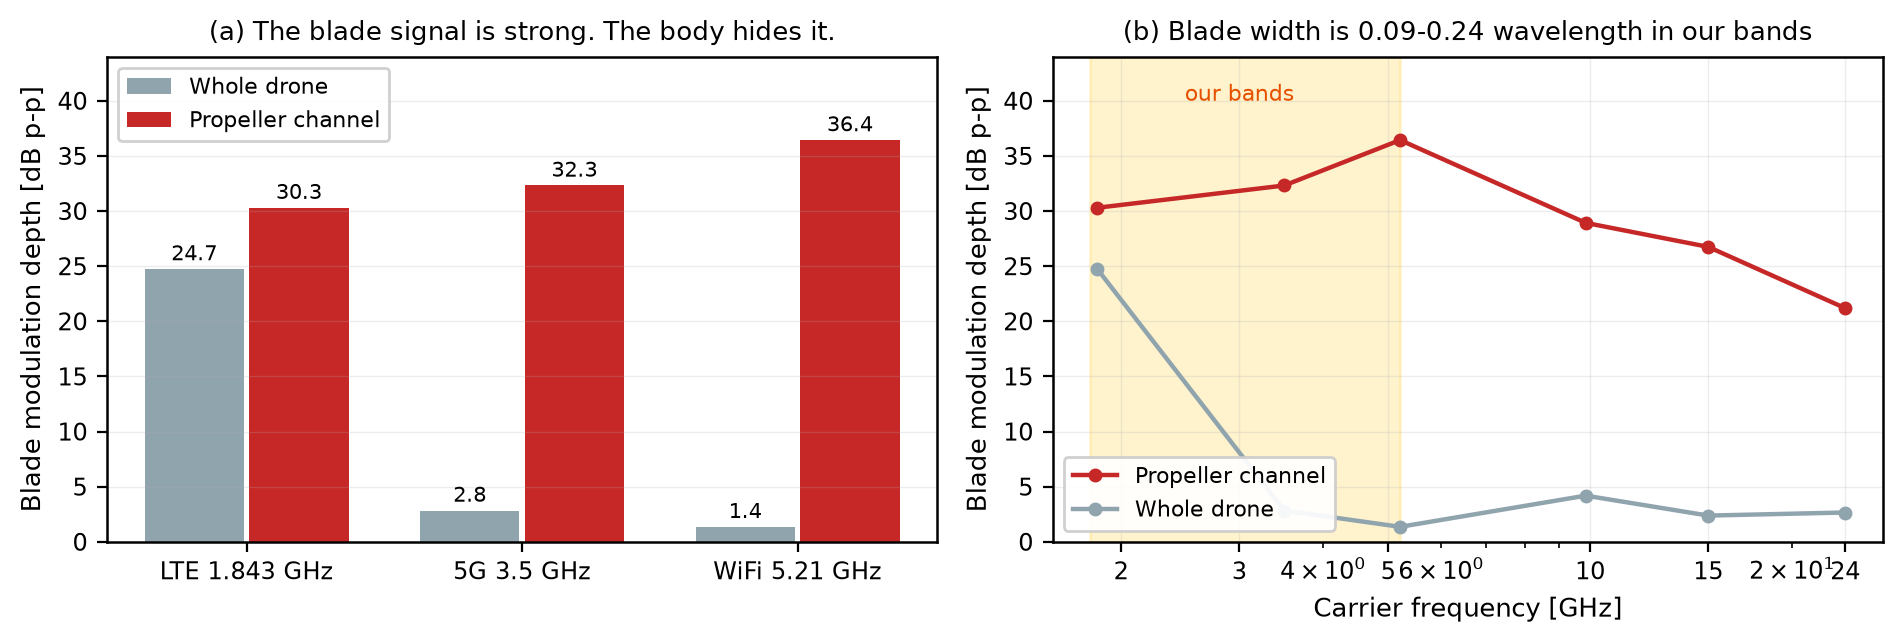

⭐ 이 편들의 핵심 발견 하나 — **블레이드 신호가 약한 게 아니라 동체가 덮고 있다.** 같은 얼린 판·같은 자세·같은 로터 회전수의 두 **B 팔** 실행을 읽으면 전체 드론 채널의 변조 깊이는 5.36 dB p-p 인데, 프로펠러 채널만 떼면 50.32 dB p-p 다(3.5 GHz · 방위 0° · 앙각 -15°) — 9 배 차이다.

레벨은 반대다 — 전체 채널 -51.6 dB 대 프로펠러 채널 -72.3 dB 로 동체 쪽이 훨씬 밝다. 두 줄을 같이 읽으면 **동체가 밝아서 변조를 눌렀다** 가 나온다 — 검출 축에서 정적 성분을 지우는 이유가 여기 있다.

⚠ **이 그림의 밴드별 dB 는 그림 빌더에 박힌 값이다**(`benchmark/build_report07_figs.py:221-222`) — 위 문단의 원장 값과 다른 판이므로 **절대 dB 는 본문에서만 인용한다**. 그림이 보이는 것은 두 채널의 **순서**다.

원장: `outputs/report15b_microdoppler.json : cells.matrice4e/belly.arms.{B_sbr_spread, F_blade_occ}`.


## 2 초 호버링 — 능선과 로터 회전수

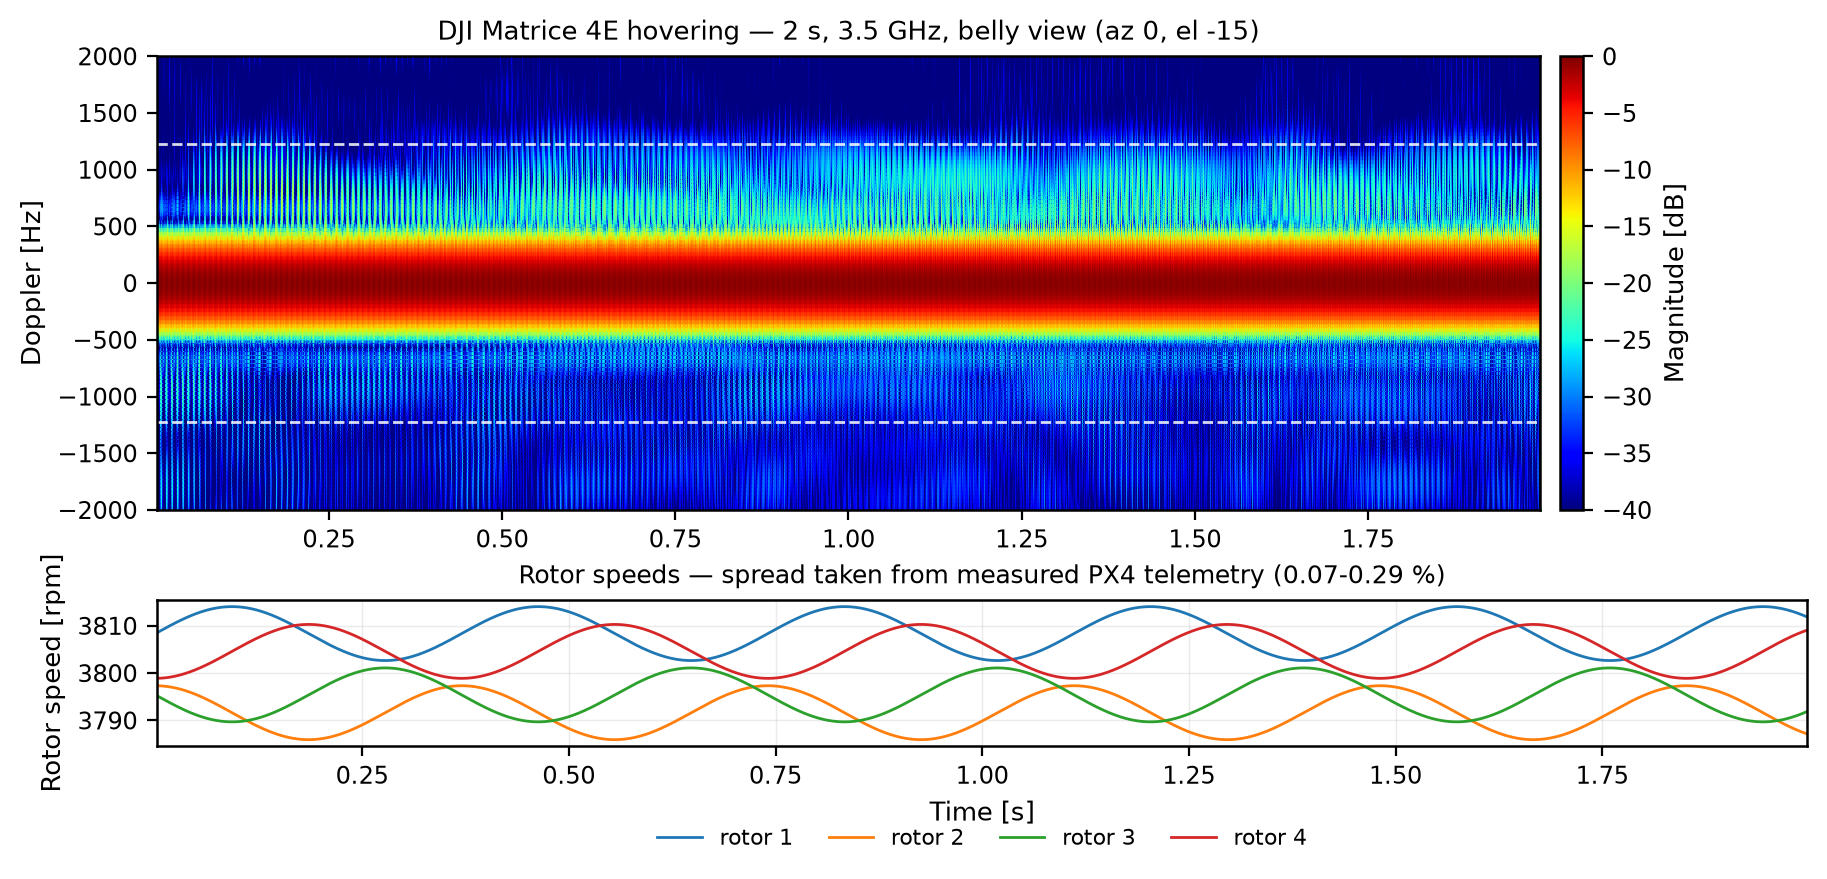

2 초 · 39,400 표본 · 253 블레이드 주기. 아래 패널이 네 로터의 회전수다 — 능선이 어떻게 움직이는지의 원인이 거기 있다.

⭐ 로터별 산포는 **0.22%** 다. 로터들이 이만큼 가까운 속도로 돌기 때문에 네 빗살이 고조파마다 정렬되고 능선이 가늘게 선다.

⚠ **이 그림과 다음 그림은 B 팔(SBR) 한 팔이다 — P 대조가 없다.** 원장이 그 사실을 스스로 적는다: ⚠ `report07_hover_long*` 두 열에는 **순수 PO 대조 팔이 없다**. 2 초 창의 능선이 이 감사에서 심판을 못 받는 유일한 자리다 — 같은 자세·같은 rpm 궤적으로 PO 팔을 한 번 돌리면(모노 PO 는 4096 자세에 8.4 초였다) 닫힌다.

⚠ 제어루프 흔들림(±0.15% @ 2.7 Hz)은 **선언된 가정**이다 — 우리 표적의 실측 비행 로그가 그 자리를 채운다.


## 로터 산포 프리셋 비교: 실내-이상 하한 vs 야외 앵커

**시나리오** — 위와 완전히 같은 계산(같은 기체·자세·2 초·SBR 팔)이고, 바꾼 것은 **로터 산포 프리셋 하나**다. 왼쪽이 실내-이상(±0.22%), 오른쪽이 **야외 프리셋**(±2% · 흔들림 ±2.5% @ 1.0 Hz)이다.

⭐ 야외 프리셋의 출처는 **논문이 아니라 공개 비행로그 데이터셋 세 종**이다 — 우리가 직접 내려받아 호버 구간을 잘라 재서 얻은 값이다.

| 데이터셋 | 기체·환경 | 신호 | 정적 산포(중앙) | 흔들림(중앙) |
|---|---|---|---|---|
| NeuroBEM (UZH RPG) | 레이싱 쿼드 · **실내** 무풍 | 모터별 실측 회전수 400 Hz | 0.54 % | 0.83 % @ 1.48 Hz |
| PX4 · CODEV AQUILA V3 | 상용 대형 쿼드 · **야외** | ESC 실측 rpm 4 Hz | 2.35 % | 2.43 % @ 0.71 Hz |
| DJI Phantom 3 DAT | ⭐**진짜 DJI** · 야외 | 모터 PWM **명령** 50 Hz | 5.67 % | 5.90 % @ 0.67 Hz |

⚠ 세 줄의 한계는 각각 다르다. 앞의 둘은 **DJI 가 아니고**, CODEV 는 표본율 4 Hz 라 나이퀴스트 2 Hz 위가 접혀 진폭이 과대측정될 수 있다. 셋째만 진짜 DJI 인데 **실측 rpm 이 아니라 PWM 명령**이라 백분율의 뜻이 앞의 둘과 다르다. 그래서 야외 프리셋 ±2 % 는 **세 줄을 합쳐 반올림한 자릿수 앵커**이지 우리 표적의 실측이 아니다.

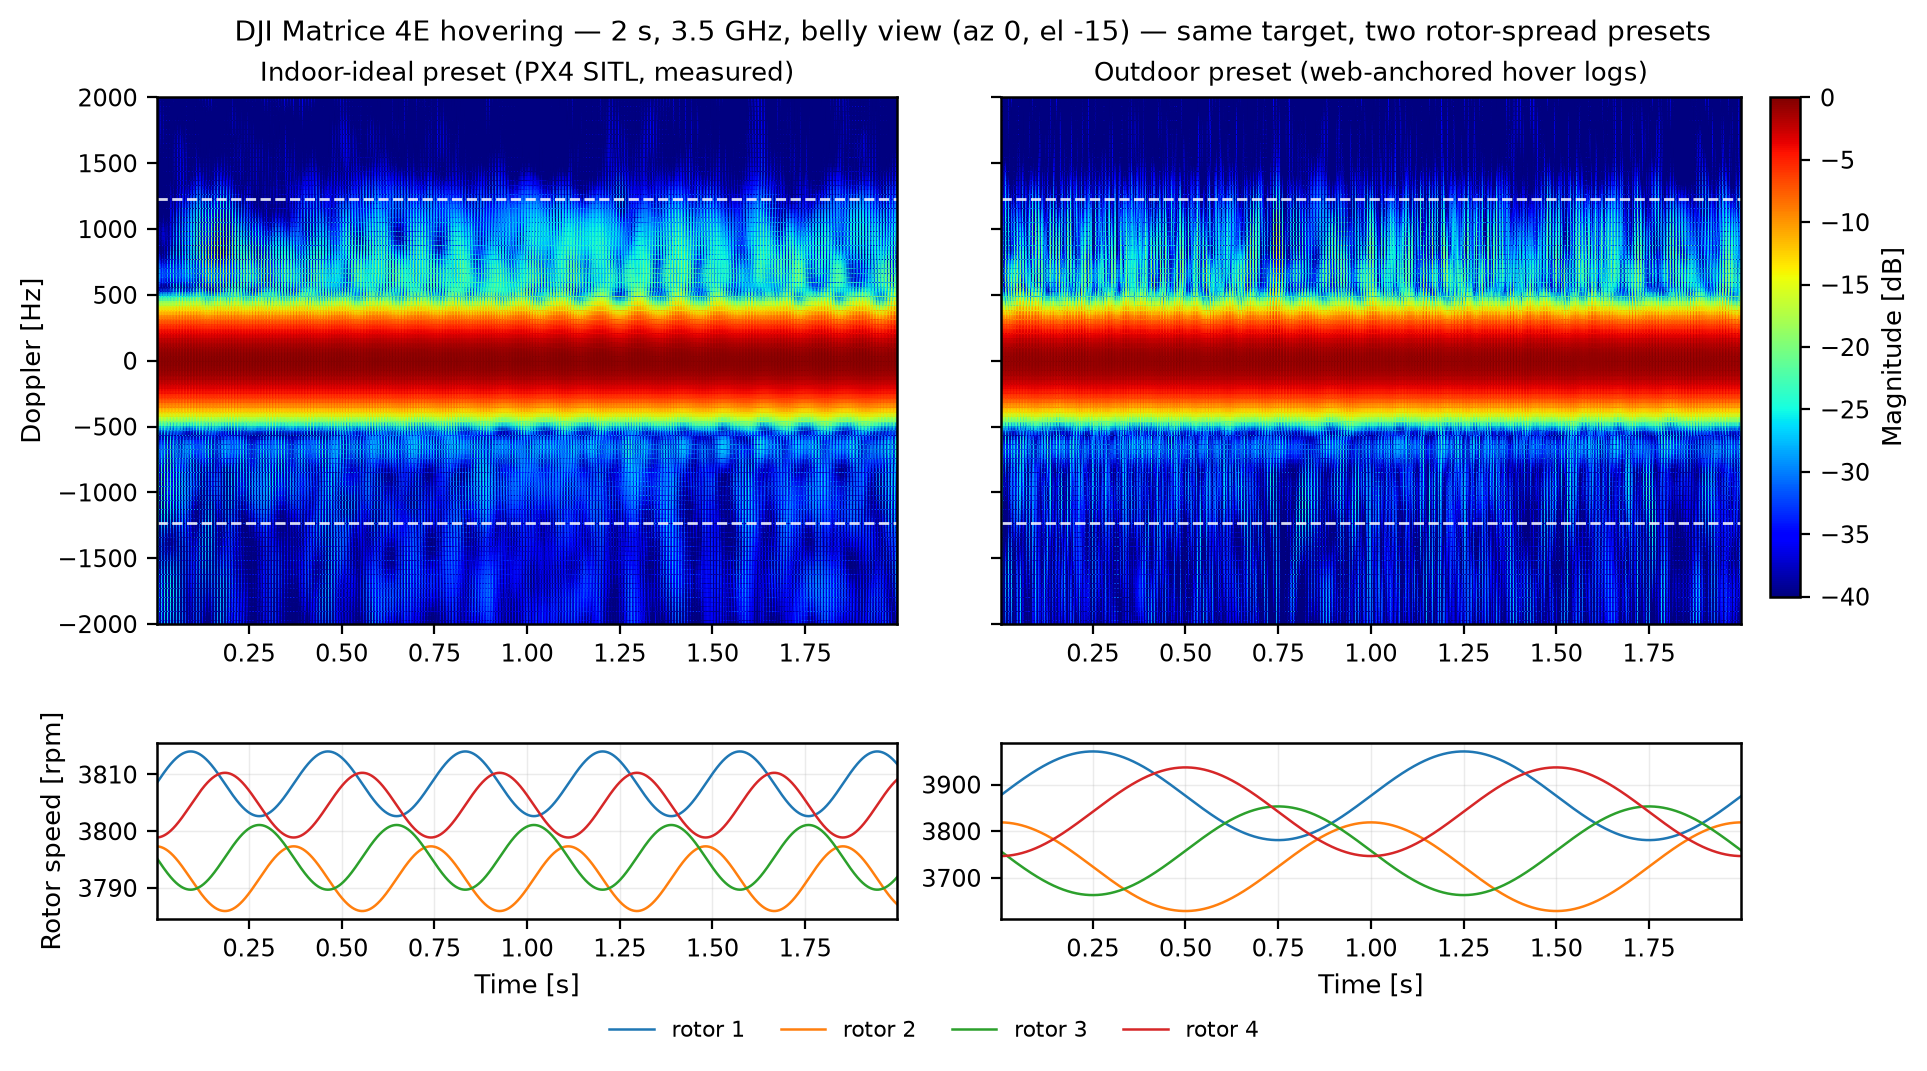

⭐ 읽는 법 — 왼쪽은 로터들이 거의 같은 속도라 고조파 빗살이 정렬된다. 오른쪽은 로터별 f_tip 이 수십 Hz 씩 갈라져 능선이 **얽힌 뱀처럼** 교차한다. ⭐⭐그런데 **세로 플래시 아치는 양쪽 다 남는다** — 산포는 능선(주파수축 구조)을 뭉개지만 플래시(시간축 사건)는 못 지운다. 시간 분해능을 우선하는 표시 규약이 야외에서 더 중요해지는 물리적 이유가 이것이다.


## 그 «야외 앵커» 를 눈으로: 공개 비행로그 세 종의 실측

위 표의 근거를 그림으로 본다. 곡선과 상자는 인용이 아니라 **그 로그를 직접 열어 우리가 잰 값**이다. 세 로그에서 호버 구간(|v| < 0.3 m/s)을 전부 뽑아 같은 규약으로 쟀다.

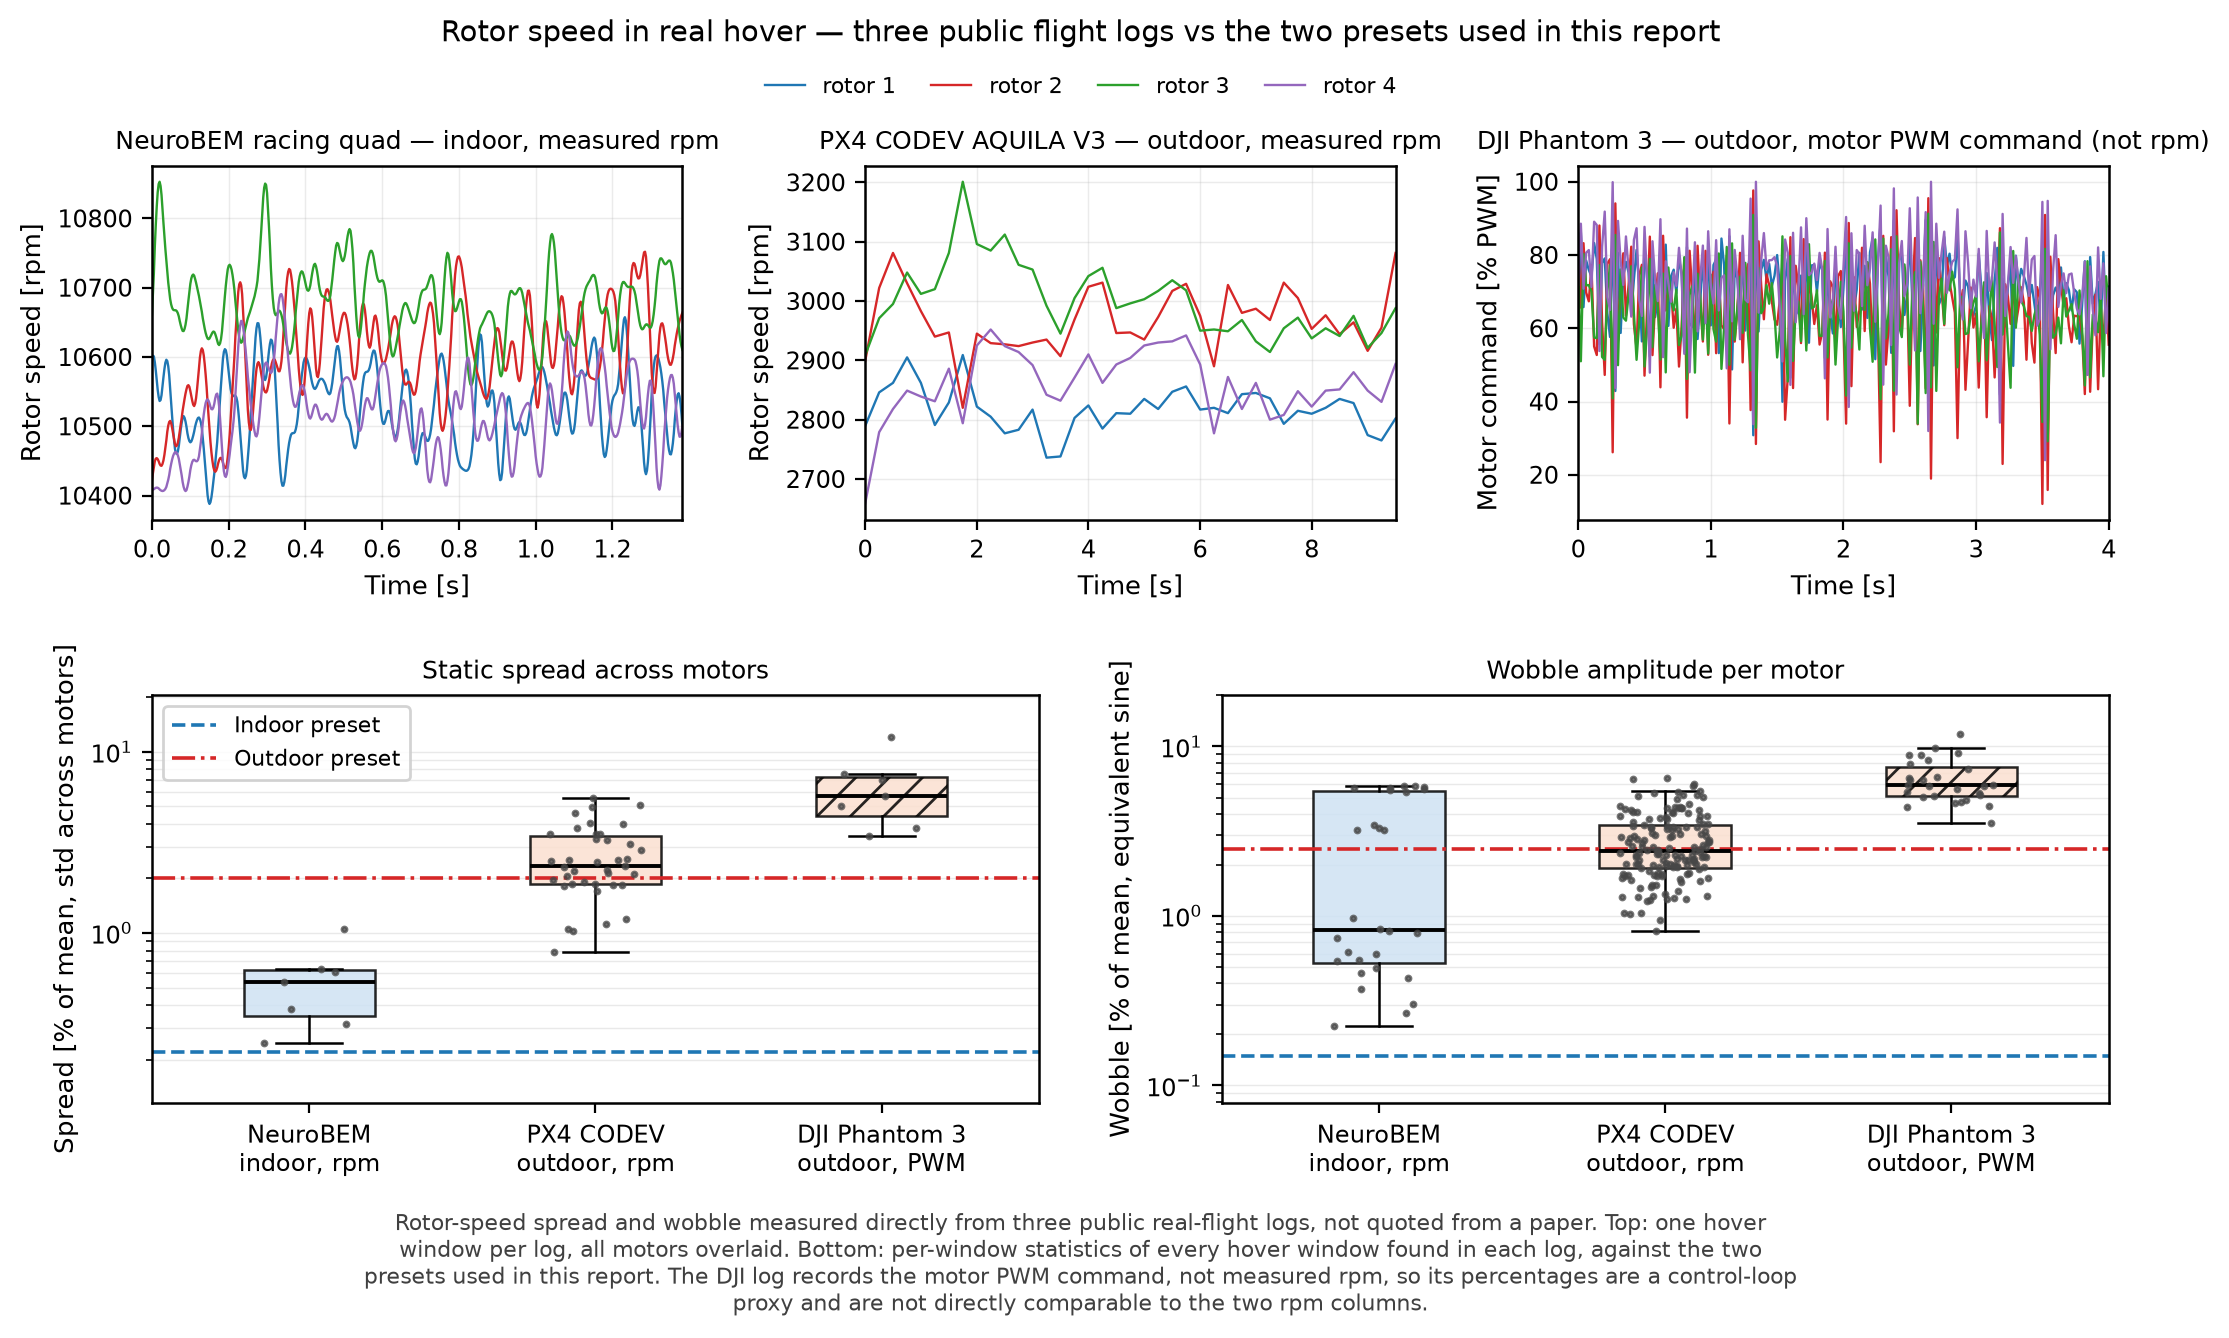

윗줄은 데이터셋마다 호버 창 하나를 골라 모터 넷을 겹쳐 그린 것이고, 아랫줄은 **찾아낸 모든 호버 창**의 산포·흔들림 분포에 우리 두 프리셋을 가로선으로 얹은 것이다. ⭐야외선이 PX4 야외 상자를 관통하고 실내선은 NeuroBEM 상자 **아래**에 놓인다.

⭐ 세 독립 원천이 **같은 방향**을 가리킨다 — SITL 유래 ±0.22 % 는 실기체 야외 호버를 한 자릿수 과소평가한다. 우리 표적(Mavic 4 Pro·Matrice 4E)의 실측 rpm 로그는 여전히 없고(Mavic Air 이후 DJI DAT 은 암호화), 그 구멍은 X410 필드테스트로만 닫힌다.


## 이 편이 서 있는 자리

무늬를 정하는 것은 **회전수의 균일함 · 동체의 가림 · 로터 산포** 셋이다.

| 다음 | 무엇을 답하나 |
|---|---|
| [08_4 무엇을 잴 수 있나](08_4_sampling.ipynb) | 광선 비용과 조명원 반복률 |
| `reports/09_microdoppler-limits.ipynb` | 자세·보정·광선 예산의 단일축 분해 |
| `reports/10_illuminators.ipynb` | 조명원별로 무엇을 쓸 수 있나 |


---

## 조각에서 이어붙인 절

아래 절 1~6 는 `reports/_parts/` 의 조각을 그대로 이어 붙인 것이다 — 같은 물음(무엇이 무늬를 정하나)에 답하기 때문이다. 각주는 이 편 안에서 다시 번호가 매겨졌다.

⭐ 이 절들을 손으로 고치지 마라. 고칠 곳은 그 조각을 만든 `src/build_partNN_*.py` 이고, 고친 뒤 `src/build_volumes.py` 를 다시 돌리면 여기가 따라 바뀐다.


---

## 절 1. 스톡 Paths.doppler 로는 블레이드 변조가 안 나온다 — SceneObject.velocity 가 객체당 강체 1벡터다



> ### 한 일
> **설치본 Sionna 의 장면 객체에 속도를 직접 넣고 경로 도플러를 읽어 자유도를 셌다.**

### 결과
1. 장면 객체 하나가 갖는 속도 자유도는 3 개 [^1] 다 — 평행이동 세 성분이고, 회전 자유도는 그 밖이다.
2. 정지 장면(**Mini 2**)에서 도플러가 0 이 아닌 경로는 0 개 [^2] (전체 98 개 [^3]) — 배선 자체는 정상이다.
3. **Matrice 4E** 의 프롭 그룹에 강체속도를 주면 **표적 경유 경로** 296 개 [^4] 가 모두 같은 부호로 몰린다 — 크기는 강체 투영에 따라 0 ~ 187.5 Hz [^5] 로 퍼지고, 그 최대가 강체 예측 181.3 Hz [^6] 와 같은 자리에 선다.
4. 전진날과 후퇴날이 갈리려면 그 둘이 반대 부호를 받아야 하는데, 자유도 3 [^1] 개짜리 벡터 하나가 그것을 표현한다.
5. 그래서 남는 길은 하나다 — 시간표본마다 자세를 새로 놓고 다시 쏘는 것이고, 그 절차가 **절 2** «슬로타임 복소열» 이다.


### 방법

| 무엇을 | 어떻게 얻었나 |
|---|---|
| 자유도 세기 | 설치본 `sionna.rt.SceneObject.velocity` 의 성분 수를 부품 객체마다 직접 읽었다 |
| 강체 주입 시험 | 프롭 그룹에만 속도 (0, 0, 30) m/s 를 주고 `Paths.doppler` 의 고유값을 셌다 |
| 대조 | 같은 장면을 정지 상태로 한 번 더 추적해 도플러가 0 인지 확인했다 |
| 무엇을 안 물었나 | Sionna 가 «회전하는 기하의 왕복 위상» 을 따라가는지는 이 시험의 밖이다 — **절 3** «두 엔진» 이 그것을 잰다 |

### 재현

```bash
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/report15_probe.py
```

| | |
|---|---|
| 출력 | `outputs/report15_probe.json` |
| 소요 | 약 7 분 (GPU 1장) |

---


## 무엇을 물었나

Sionna 는 장면 객체에 속도를 주면 경로마다 도플러를 계산해 준다. 그 기능만으로 **블레이드 마이크로도플러**(도는 날개가 만드는 변조)가 나오는지가 첫 갈래다.

나온다면 로터를 돌리는 비싼 길을 건너뛴다. 안 나온다면 시간표본마다 자세를 다시 놓고 광선을 다시 쏘는 길로 간다. 두 길의 비용 차이가 커서 먼저 확인했다.


## 자유도를 세면 답이 정해진다

| 무엇을 | 기체 | 값 |
|---|---|---|
| 객체당 속도 자유도 | Mini 2 | 3 개 [^1] |
| 정지 장면의 0 아닌 도플러 | Mini 2 | 0 개 [^2] |
| 강체속도 주입 시 표적 경유 경로 | Matrice 4E | 296 개 [^4] |
| 그 경로의 도플러 최대 | Matrice 4E | 187.5 Hz [^5] |
| 강체 운동학이 예측하는 값 | Matrice 4E | 181.3 Hz [^6] |

프롭 전체에 강체속도 하나를 주면 표적 경유 경로가 전부 같은 부호로 몰리고, 크기는 각 경로의 강체 투영에 따라 0 부터 표의 최대값까지 퍼진다 — 그 최대값이 강체 예측과 같은 자리에 선다. 블레이드 전진/후퇴가 갈라지려면 부호가 반대인 두 값이 나와야 하는데, 이 표의 도플러는 한 부호로 몰린다.


## 표의 두 줄은 잣대가 다르다

«표적 경유 경로» 는 `outputs/report15_probe.json : airframes.matrice4e.A_doppler.rigid_prop_velocity.n_target_paths` 이고, 그 키는 표적의 어느 부품이든 스친 경로를 전부 센다 — 프롭만 센 수는 따로 세야 한다. 판정은 그대로 선다: 경로 집합이 넓을수록 부호가 갈릴 기회가 많은데도 도플러가 한 부호로 몰린다.

위 두 줄은 **Mini 2**, 아래 세 줄은 **Matrice 4E** 다. 자유도 세기는 두 기체에서 같은 답을 낸다 — `outputs/report15_probe.json : airframes.*.A_doppler.velocity_dof_per_object` 의 모든 부품이 평행이동 세 성분뿐이라, 판정이 기체 선택에 안 걸린다.


## 이것은 구현 문제가 아니라 자료구조 문제다

속도가 객체당 벡터 하나라는 것은 «그 객체가 강체로 평행이동한다» 는 뜻이다. 회전하는 프로펠러는 같은 객체 안에서 점마다 속도가 다르고, 그 차이를 담을 자리가 벡터 하나 밖에 있다.

부품을 날개 하나하나로 쪼개도 마찬가지다 — 날개 하나 안에서도 뿌리와 끝의 속도가 다르고, 그 차이가 바로 날개끝 확산을 만드는 양이다.

판정 문장은 산출물에 그대로 있다 — `outputs/report15_verdict.json : branch1_paths_doppler.answer`.


## 다음 단계

| 다음에 할 일 | 그러면 결정되는 것 | 어디서 |
|---|---|---|
| 시간표본마다 자세를 새로 놓고 다시 쏜다 | 블레이드 변조를 만드는 유일한 길이 실제로 작동하는지가 갈린다 | **절 2** «슬로타임 복소열» |
| Sionna 가 회전 기하의 왕복 위상을 따라가는지 우리 커널과 맞댄다 | 위상을 광선 엔진에 맡길 수 있는지가 정해진다 | **절 3** «두 엔진» |


<!--rs:sources-->
## 출처

본문의 `[^n]` 은 아래 6개 중 하나를 가리킨다. 값은 이 표를 만들 때 JSON 을 다시 열어 채웠다 — 본문 숫자와 같은 파일, 같은 키다.

| | 파일 | 키 | 값 |
|---|---|---|---|
| [^1] | `outputs/report15_verdict.json` | `branch1_paths_doppler.evidence.max_dof` | 3 |
| [^2] | `outputs/report15_verdict.json` | `branch1_paths_doppler.evidence.doppler_nonzero_paths_static_scene` | 0 |
| [^3] | `outputs/report15_verdict.json` | `branch1_paths_doppler.evidence.n_paths` | 98 |
| [^4] | `outputs/report15_probe.json` | `airframes.matrice4e.A_doppler.rigid_prop_velocity.n_target_paths` | 296 |
| [^5] | `outputs/report15_probe.json` | `airframes.matrice4e.A_doppler.rigid_prop_velocity.doppler_max_hz` | 187.5 |
| [^6] | `outputs/report15_probe.json` | `airframes.matrice4e.A_doppler.rigid_prop_velocity.predicted_rigid_hz` | 181.3 |


---

## 절 2. 시간표본마다 자세를 새로 놓고 다시 쏘아 슬로타임 복소열을 만든다



> ### 한 일
> **로터 위상을 시간표본마다 다시 놓고 광선을 다시 쏘아 되돌아오는 복소 신호의 느린 시간축을 만들었다.**

### 결과
1. 헤드라인 칸은 DJI Matrice 4E [^7] 를 배 쪽에서 본 것이다 — 방위 0 도 [^8] · 앙각 -15 도 [^9].
2. 호버 3800 rpm [^10] 에서 운동학이 예측하는 날개끝 주파수는 1230 Hz [^11], 블레이드 통과율은 126.7 Hz [^12] 다.
3. 표본율 19700 Hz [^13] 로 6000 개 [^14] 를 이어 붙여 창 길이 0.505 s [^15] 를 얻었다.
4. 그 창이 주는 도플러 분해능은 1.98 Hz [^16] 이고, 날개끝까지 621 칸 [^17] 이 든다.
5. 조립을 싸게 만든 것은 `src/articulated_fast.py` 다 — 드론을 한 번 짓고 위상마다 행렬곱만 한다.


### 방법

| 무엇을 | 어떻게 얻었나 |
|---|---|
| 슬로타임 복소열 | 시간표본마다 로터 위상을 다시 놓고 광선을 다시 쏜다 — 위상 하나짜리 표를 쓰지 않으므로 로터마다 회전수를 다르게 줄 수 있다 |
| 무엇이 그것을 가능하게 했나 | `src/articulated_fast.py` — 드론을 한 번 짓고 위상마다 행렬곱만 한다. 정점 배열이 옛 함수와 비트 단위로 같다 |
| 도플러 분해능 | 창에 든 블레이드 주기 수가 정한다. 표본 수를 늘려도 안 좋아진다 |
| 헤드라인 기체 선택 | DJI Matrice 4E — 프롭·벨 겹침이 0.01 % 로 정리됐고 1차 실측 표적이다 |

### 재현

```bash
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/report15b_microdoppler_recompute.py
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/report15b_stamp_provenance.py
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/build_report15b_figs.py
```

| | |
|---|---|
| 출력 | `outputs/report15b_microdoppler.json`, `outputs/report15b_series.npz` |
| 소요 | 약 25 분 (GPU 1장 — 광선 추적이 6칸 × 4팔) |
| 비고 | 산출물이 자기가 어떤 메쉬로 계산됐는지 지문을 함께 적는다(`mesh_provenance`) — 계산 도중 메쉬가 바뀌면 스스로 경고한다 |

### 앞 편에서

| 어디서 | 무엇을 알고 와야 하나 |
|---|---|
| 앞 편 | **절 1** «스톡 도플러» — 왜 이 길로 가나 |

---


## 무엇을 재는가

표적이 제자리에 떠 있어도 날개는 돈다. 날개 표면의 점들이 시간에 따라 자리를 바꾸므로 왕복 위상이 변조되고, 그것이 되돌아오는 신호의 느린 시간축에 실린다. 우리는 그 열을 **시간표본마다 자세를 새로 놓고 광선을 다시 쏘아** 만든다.

왜 그렇게까지 하는가. 로터마다 회전수를 다르게 주려면 드론 전체 자세가 각도 하나의 함수가 아니게 되고, 그러면 «위상 하나짜리 표를 미리 만들어 두고 조회한다» 는 지름길이 막힌다. 조립을 싸게 만들어 그 지름길을 버렸다.


## 헤드라인 칸의 운동학

| 무엇을 | 값 |
|---|---|
| 기체 · 자세 | DJI Matrice 4E [^7] · 배 쪽 |
| 방위 · 앙각 | 0° [^8] · -15° [^9] |
| 호버 회전수 | 3800 rpm [^10] |
| 날개끝 속도 | 54.52 m/s [^18] |
| 날개끝 주파수 | 1230 Hz [^11] |
| 블레이드 통과율 | 126.7 Hz [^12] |


## 창이 분해능을 정한다

| 무엇을 | 값 |
|---|---|
| 표본율 | 19700 Hz [^13] |
| 표본 수 | 6000 개 [^14] |
| 창 길이 | 0.505 s [^15] |
| 도플러 분해능 | 1.98 Hz [^16] |
| 날개끝까지 든 칸 수 | 621 칸 [^17] |

분해능은 «창에 든 블레이드 주기 수» 가 정한다. 같은 창 안에서 표본을 촘촘히 해도 칸이 좁아지지 않으므로, 능선을 가르려면 창을 늘린다.


## 전처리를 어떻게 했는가

마이크로도플러 그림은 전처리가 답을 바꾼다. 그래서 규약을 적어 둔다.

| 단계 | 우리가 한 것 | 왜 |
|---|---|---|
| 채널 | 전체 드론과 프로펠러만을 따로 | 동체가 블레이드를 덮는다 |
| 0 도플러 | **살린다** | 동체 선이 읽기의 기준이다 |
| 조각 길이 | 블레이드 13 주기 | 능선 사이에 13 빈이 들어 빗살이 안 뭉갠다 |
| 창·제로패딩 | Hann · 4배 | 누설을 줄이고 주파수축을 매끈하게 |
| 색역 | 60 dB | 동체 선을 0 dB 로 두고 능선을 그 아래에서 읽는다 |
| 정규화 | 한 그림 안에서 공통 | 두 패널을 나란히 놓고 비교할 수 있게 |


## 검출 축의 전처리는 따로 있다

정적 성분을 지우는 슬로타임 고역통과(MTI)는 `src/microdoppler_proc.py` 에 따로 있다 — **검출 축**에서 쓴다. ⚠ 그 노치는 호버하는 표적의 동체도 함께 지우므로 탐지에서는 대가가 된다.

⚠ 선행 구현의 **처리 파라미터**는 그 시스템의 자원격자에 맞춰진 값이라 그대로 옮기지 않았다. 우리가 가져온 것은 그림을 읽는 순서이고, 차단주파수 같은 것은 우리 물리에서 정했다.


## 다음 단계

| 다음에 할 일 | 그러면 결정되는 것 | 어디서 |
|---|---|---|
| 같은 절차를 두 엔진에 태워 무늬를 맞댄다 | 위상을 광선 엔진에 맡기고 세기를 PO 커널에 맡기는 분업이 근거를 얻는다 | **절 3** «두 엔진» |
| 로터마다 회전수를 다르게 준다 | 무늬가 시간에 따라 변하는 데 무엇이 필요한지가 갈린다 | **절 4** «회전수 축» |


<!--rs:sources-->
## 출처

본문의 `[^n]` 은 아래 12개 중 하나를 가리킨다. 값은 이 표를 만들 때 JSON 을 다시 열어 채웠다 — 본문 숫자와 같은 파일, 같은 키다.

| | 파일 | 키 | 값 |
|---|---|---|---|
| [^7] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.name` | DJI Matrice 4E |
| [^8] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.az_deg` | 0 |
| [^9] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.el_deg` | -15 |
| [^10] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.physics.rpm` | 3800 |
| [^11] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.physics.f_tip` | 1230 |
| [^12] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.physics.f_flash` | 126.7 |
| [^13] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.physics.prf` | 19700 |
| [^14] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.physics.n_t` | 6000 |
| [^15] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.physics.duration_s` | 0.5053 |
| [^16] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.physics.doppler_resolution_hz` | 1.979 |
| [^17] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.physics.bins_to_ftip` | 621.3 |
| [^18] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.physics.v_tip` | 54.52 |


---

## 절 3. 두 엔진이 날개끝 주파수 아래에서 겹치고 그 위에서 갈린다



> ### 한 일
> **같은 로터 위상 스텝 절차를 스톡 Sionna 엔진과 우리 PO 커널 두 곳에 태워 같은 칸에서 나온 무늬를 맞댔다.**

### 결과
1. 운동학이 예측한 날개끝 주파수 **아래**에서 두 빗살이 겹친다 — 변조 깊이가 Sionna 10.91 dB [^19] · 순수 PO 17.70 dB [^20] 다(**nose · 3 m [^21] 한 칸**).
2. 그 위에서 갈린다 — 기하 절벽 너머 꼬리의 최대값이 Mini 2 에서 Sionna -19.56 dB [^22] 대 순수 PO -36.14 dB [^23] 다(**자세 5 × 거리 1·3·10 m = 15 칸 [^24] 의 중앙값**).
3. Sionna 의 빗이 **기하에서 온다** — 산란 물리를 전부 빼고 왕복 위상만 더한 기준과 겹치면 Mini 2 9 [^25]/10 [^26] 칸이 ±1 조화 안에서 일치한다(**근거리 1·3 m 칸**).
4. 빗 모양 코사인 중앙값은 Mini 2 0.9639 [^27] · Matrice 4E 0.8714 [^28] 다(**같은 15 칸의 중앙값**).
5. ⭐ 아래쪽에서 겹친다는 것이 «위상은 광선 엔진이 맞게 낸다» 의 근거이고, 위쪽에서 갈린다는 것이 «세기는 PO 커널이 맡는다» 의 근거다.


### 방법

| 무엇을 | 어떻게 얻었나 |
|---|---|
| 같은 격자 | 로터 위상 스텝·거리·자세·재질·주파수를 전부 같게 두고 엔진 하나만 바꿨다 |
| 팔 셋 · 이 편의 낱말 | **S** = Sionna PathSolver · **B** = Ours (SBR+PO, 기본) · **P** = Ours, nothing blocked (control). 절마다 어느 팔이 재었는지를 이 세 이름으로 적는다 |
| Sionna 팔 (S) | 스톡 `sionna.rt.PathSolver` — h = Σ a_p·exp(−j2πf_c τ_p). `Paths.cir()` 은 절대위상을 지우므로 쓰지 않는다 |
| 순수 PO 팔 (P) | `src/microdoppler_nearfield.py` — 평면파/구면파 PO 표면적분. 광선 격자를 안 쓰고 가림도 안 푼다 |
| SBR 팔 (B) | `src/rcs_sbr.py::sbr_field` — 광선 격자로 보이는 면을 골라 PO. 그림 2 의 가운데 칸이 이 팔이고, 결과 1~4 의 두 열은 S 와 P 다 |
| 통계 단위 | 결과 1 은 nose · 3 m **한 칸**, 결과 2~4 는 자세 5 × 거리 1·3·10 m = **15 칸의 중앙값**, 그림 2 는 belly · 앙각 −15° · 3 m **한 칸**이다 |
| 비교 가능한 양만 | 절대 스케일과 기준위상이 다르므로 상수 복소배에 불변인 양(AC 상관 · dB ptp · 하모닉 스펙트럼)만 맞댔다 |
| 기하 기준 | 같은 메쉬로 산란 물리를 빼고 왕복 위상만 더한 빗 — 움직이는 기하가 원리적으로 낼 수 있는 도플러 빗이다 |

### 재현

```bash
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/report15_po_control.py
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/report15_verdict_geomref.py
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/report15_verdict.py
```

| | |
|---|---|
| 출력 | `outputs/report15_po_control.json`, `outputs/report15_verdict_geomref.json`, `outputs/report15_verdict.json` |
| 소요 | 약 30 분 (GPU 1장) |

### 앞 편에서

| 어디서 | 무엇을 알고 와야 하나 |
|---|---|
| 앞 편 | **절 2** «슬로타임 복소열» — 두 엔진에 태운 절차 |

---


## 같은 로터를 두 엔진이 돌린다

![report07_f2](../outputs/figures/report07_f2.png)

**그림 1.** Sionna 자체 엔진과 우리 순수 PO 대조팔이 같은 로터에서 같은 무늬를 내는가?
로터 위상을 스텝하고 매번 다시 추적하는 같은 절차를 **두 팔**에 태웠다 — **S** = Sionna PathSolver 와 **P** = Ours, nothing blocked (control) 다. 이 그림은 **nose · 3 m 한 칸**이고 기선은 0.2 m 다(준-모노스태틱).

운동학이 예측한 날개끝 주파수 **아래**에서 두 빗살이 겹친다. 가림을 푸는 SBR 팔(B)은 이 그림 밖에 있고, 아래 «세 엔진을 같은 격자에» 절이 그 팔을 세운다.


## 그 위에서 갈린다

잰 팔은 **S** 와 **P** 둘이고, 셋째 열은 산란 물리를 뺀 기하 기준이다 — **자세 5 × 거리 1·3·10 m = 15 칸 [^24] 의 중앙값**이다.

| 기체 | S 꼬리 최대 | P 꼬리 | 기하 기준 꼬리 |
|---|---|---|---|
| Mini 2 | -19.56 dB [^22] | -36.14 dB [^23] | -26.52 dB [^29] |
| Matrice 4E | -24.60 dB [^30] | -35.83 dB [^31] | -29.85 dB [^32] |

Sionna 의 꼬리가 PO·기하 기준보다 뚜렷하게 높게 남는다. 그 꼬리는 블레이드가 만든 것이 아니므로, 가장자리를 자동으로 찾는 검출기는 물리적이지 않은 자리를 가장자리라고 보고한다. 그 꼬리의 원인은 [리포트 9 절 3 «광선예산»](09_microdoppler-limits.ipynb) 이 잰다.


## 세 엔진을 같은 격자에 태우면

![report07_f5](../outputs/figures/report07_f5.png)

**그림 2.** Sionna·SBR·PO 를 같은 슬로타임 격자에 태우면 같은 무늬가 나오는가?
같은 기체·자세·주파수·PRF·로터별 회전수로 세 팔을 돌렸다 — 4096 표본 [^33] @ PRF 19700 Hz [^34] = 26 [^35] 블레이드 주기. 이 그림과 표는 **belly · 앙각 -15° [^36] · 3 m [^37] 한 칸**이다.

| 팔 | 무엇으로 쟀나 | 변조 p-p | 전체 전력 중 날개끝 밖 | 무늬 |
|---|---|---|---|---|
| S | Sionna PathSolver | 32.6 dB [^38] | 5.06% [^39] | 얼룩이 대역을 채우고 날개끝 주파수 밖에도 남는다 |
| B | Ours (SBR+PO, 기본) | 5.3 dB [^40] | 0.18% [^41] | 빗살이 또렷하다 — ⚠순수 PO 보다는 여전히 35 dB [^42] 위다 |
| P | Ours, nothing blocked (control) | 2.8 dB [^43] | 0.00007% [^44] | 빗살이 가장 좁고 날개끝에서 절벽처럼 잘린다 |

⭐ 셋 다 (a) 0 도플러 동체 선, (b) 블레이드 통과율 간격 능선, (c) 날개끝 주파수 근처 감쇠를 낸다 — **구조가 일치한다**. 날개끝 주파수 안에서 스펙트럼 코사인이 0.745 [^45] (Sionna↔SBR) · 0.760 [^46] (Sionna↔PO) · 0.955 [^47] (SBR↔PO) 다.


## 그 코사인은 «닮았다» 까지를 말한다

위 코사인이 말하는 것은 «대역 안에서 무늬의 모양이 닮았다» 까지다. 세 엔진은 능선의 **세기와 밀도**에서 크게 갈리고, 갈리는 방향에 각각 이유가 있다.

| 팔 | 무엇이 그렇게 만드나 |
|---|---|
| P Ours, nothing blocked (control) | 가림을 빼고 계산하므로 모든 면이 항상 기여한다 → 변조가 씻긴다 |
| B Ours (SBR+PO, 기본) | 가림이 켜져 있어 능선이 굵다. 격자를 얼린 뒤 날개끝 밖에 남는 몫은 0.18% [^41] 이고, 그래도 순수 PO 보다 35 dB [^42] 위다 |
| S Sionna PathSolver | 경로가 열 개 남짓이라 표본이 성기고, 날개끝 밖에 5.06% [^39] 이 남는다 |

⭐ **날개끝 밖에 남던 능선의 원인은 광선 격자의 이산화가 아니라 자세마다 격자를 다시 정의하는 것이었다.** 격자를 촘촘히 해도 λ/12 → λ/32 에서 대역밖 절대 전력이 2.3 dB [^48] 만 내려간다 — 기울기 -0.56 [^49] 이고, d² 이산화 잡음이면 −2 여야 한다.

격자를 얼리면 같은 광선 수로 13.1 dB [^50] 내려가면서 기울기가 -2.19 [^51] 로 예측에 붙는다. **순수 PO 팔(P)을 잣대로 놓으면** 얼린 팔의 대역 안 일치도가 0.440 [^52] 에서 0.953 [^53] 으로 오른다. 기전과 대가는 [리포트 5 절 1 «커널이 하는 일»](05_kernel.ipynb) 이 잰다.


## 얼리기의 판정은 잣대로 삼은 팔이 정한다

⭐ **Sionna 팔(S)을 잣대로 놓으면 같은 원장이 반대로 움직인다** — 같은 격자(λ/12)에서 0.727 [^54] 에서 0.662 [^55] 로 내려가고, 사다리의 다섯 격자(λ/8 · λ/12 · λ/16 · λ/24 · λ/32) 전부에서 같은 방향이다.

| 격자 | P 잣대 (prod → froz) | S 잣대 (prod → froz) |
|---|---|---|
| λ/8 | 0.514 [^56] → 0.955 [^57] | 0.743 [^58] → 0.695 [^59] |
| λ/12 | 0.440 [^52] → 0.953 [^53] | 0.727 [^54] → 0.662 [^55] |
| λ/16 | 0.426 [^60] → 0.968 [^61] | 0.722 [^62] → 0.603 [^63] |
| λ/24 | 0.428 [^64] → 0.976 [^65] | 0.722 [^66] → 0.633 [^67] |
| λ/32 | 0.428 [^68] → 0.983 [^69] | 0.721 [^70] → 0.622 [^71] |

두 잣대가 재는 것이 다르다 — P 는 광선을 아예 안 쓰는 팔이라 격자를 얼리면 가까워지고, S 는 경로가 성긴 팔이라 그 성김이 얼리기와 함께 움직인다. 그래서 이 절의 판정은 **순수 PO 를 잣대로 놓았을 때** 성립한다고 적는다.


## 얼리기가 블레이드 대역에 한 일

⭐ 같은 재계산에서 **블레이드 대역 안**의 전력도 중앙값 -13.9 dB [^72] 내려갔다. 그것이 표적의 운동이었다면 얼리기가 물리를 지운 것이므로, 판정을 광선을 안 쓰는 엔진에게 맡겼다 — 블레이드 대역이 순수 PO 보다 +20.3 dB [^73] 위에 있던 것이 +4.0 dB [^74] 로 줄었고 PO 밑으로 내려간 열은 0 [^75] 개다. 같은 대역의 복소 일치는 0.34 [^76] → 0.75 [^77] 로 오르고, 플래시 대조비는 18 [^78]/27 [^79] 열에서 +3.0 dB [^80] 올라간다 — 자의 흔들림이 골짜기를 메우고 있었다는 뜻이다 [^81].

⚠ 대가는 비율 쪽에 있다 — 동체가 든 열에서 «대역밖 ÷ 블레이드 대역» 이 -8.8 dB [^82] 에서 -6.2 dB [^83] 로 올라간다(순수 PO 는 -29.6 dB [^84]). 잉여가 사라진 만큼 남은 잔차가 상대적으로 커 보이는 것이고, 그 잔차가 지금 이 맵의 동적범위 상한이다 [^85].

⭐ **이 편의 맵은 그 얼린 판으로 다시 났다.** 옛 판과의 전후 비교(레벨 · 변조 깊이 · 대역밖 전력 · 가산성)는 8 권의 «광선 격자를 어디에 매나» 절이 낸다. ⚠ 아직 옛 판인 것은 바이스태틱 스윕 원장과 PO 대조 원장이다.


## Sionna 의 빗은 기하에서 온다

잰 팔은 **S** 하나이고, 맞대는 상대는 산란 물리를 뺀 기하 기준이다.

| 기체 | ±1 조화 안 일치 (근거리 1·3 m 칸) | 빗 모양 코사인 중앙값 (15 칸) |
|---|---|---|
| Mini 2 | 9 [^25] / 10 [^26] | 0.9639 [^27] |
| Matrice 4E | 9 [^86] / 10 [^87] | 0.8714 [^28] |

같은 메쉬로 산란 물리를 전부 빼고 왕복 위상만 더한 빗과 Sionna 의 빗을 겹치면 근거리에서 거의 모든 칸이 ±1 조화 안에서 맞는다. 즉 스톡 PathSolver 는 **회전하는 기하의 왕복 위상을 제대로 따라간다** — 그 빗은 몬테카를로 잡음의 산물이 아니다.


## 프롭 정반사가 잡히느냐는 예산이 아니라 앙각이 정한다

⭐ **이 소절의 숫자는 전부 스톡 팔(S) 하나에서 나온다** — 광선 예산 사다리와 경로 인구조사, 그 둘뿐이다.

자세×로터위상 1,152 칸 [^88] 전수에서 프로펠러에 떨어진 정반사 경로는 0 칸 [^89] 이다(**이 인구조사의** 자세 격자 = 앙각 0~60° [^90]).

그 «0» 이 표적의 물리인지 격자의 성질인지 가르려고 축을 **두 개** 따로 열었다 — 광선을 사다리로 올리는 **예산 축**과, 프롭 법선이 향하는 가파른 쪽까지 여는 **앙각 축**이다.

| 기체 | 예산 꼭대기 | 그 예산의 프롭 정반사 | 앙각 85° [^91] 까지 열면 | 무엇이 갈랐나 |
|---|---|---|---|---|
| Matrice 4E | 4,096,000,000 발 [^92] | 0 칸 [^93] | 2 칸 [^94] / 960 칸 [^95] | 앙각 |
| Mini 2 | 4,096,000,000 발 [^96] | 0 칸 [^97] | 0 칸 [^98] / 960 칸 [^99] | 둘 다 아니다 |

⭐ **두 기체가 갈린다.** Matrice 4E 는 광선을 사다리 꼭대기까지 올려도 0 칸인데 가파른 앙각을 열면 프롭 정반사가 나온다 — 그 «0» 은 격자가 프롭 법선 근처를 안 본 결과다. Mini 2 는 예산 꼭대기에서도 앙각 끝에서도 0 칸이라, 이 기체에 대해서만 «스톡 RT 가 프롭 정반사를 못 낸다» 에 가까워진다.

⇒ 그래서 **이 인구조사의** 자세 격자(앙각 0~60° [^90])에서 스톡 팔이 내는 무늬는 전부 흩어져 되돌아오는 반사에서 나오고, 그 값은 광선을 다시 쏠 때마다 흔들린다.

⚠ **이 편의 맵은 다른 격자에 산다** — 앙각 -15° [^36] 한 칸이다. 두 격자는 따로 읽는다.

**위상은 광선 엔진이, 세기는 PO 커널이 맡는** 분업의 근거는 이 절 그림 1·2 의 두 팔 대조이고, 이 인구조사는 거기에 **스톡 팔 쪽 한계**를 보탠다.


## 다음 단계

| 다음에 할 일 | 그러면 결정되는 것 | 어디서 |
|---|---|---|
| 가장자리 판정을 꼬리 초과분과 함께 다시 낸다 | «가장자리» 가 물리적 절벽인지 꼬리인지가 칸마다 갈린다 | [리포트 9 절 3 «광선예산»](09_microdoppler-limits.ipynb) |
| SBR 팔의 일치도를 15 칸 격자 전체로 넓힌다 | 한 칸에서는 그림 2 가 이미 쟀다(SBR↔PO 0.955 [^47]) — 남은 것은 그 값이 자세·거리에 얼마나 걸리는지다 | `src/rcs_sbr.py` 팔을 15 칸 격자에 |


<!--rs:sources-->
## 출처

본문의 `[^n]` 은 아래 81개 중 하나를 가리킨다. 값은 이 표를 만들 때 JSON 을 다시 열어 채웠다 — 본문 숫자와 같은 파일, 같은 키다.

| | 파일 | 키 | 값 |
|---|---|---|---|
| [^19] | `outputs/report00_microdoppler.json` | `rows[1].ptp_sionna_db` | 10.91 |
| [^20] | `outputs/report00_microdoppler.json` | `rows[1].ptp_po_db` | 17.7 |
| [^21] | `outputs/report00_microdoppler.json` | `_meta.range_m` | 3 |
| [^22] | `outputs/report15_verdict.json` | `tail_excess.by_airframe.mini2.sionna_tail_max_db_median` | -19.56 |
| [^23] | `outputs/report15_verdict.json` | `tail_excess.by_airframe.mini2.po_tail_max_db_median` | -36.14 |
| [^24] | `outputs/report15_verdict.json` | `tail_excess.by_airframe.mini2.n_cells` | 15 |
| [^25] | `outputs/report15_verdict.json` | `geometric_phase_reference.by_airframe.mini2.n_near_within_1_bin` | 9 |
| [^26] | `outputs/report15_verdict.json` | `geometric_phase_reference.by_airframe.mini2.n_near_cells` | 10 |
| [^27] | `outputs/report15_verdict.json` | `geometric_phase_reference.by_airframe.mini2.comb_shape_cosine_median` | 0.9639 |
| [^28] | `outputs/report15_verdict.json` | `geometric_phase_reference.by_airframe.matrice4e.comb_shape_cosine_median` | 0.8714 |
| [^29] | `outputs/report15_verdict.json` | `tail_excess.by_airframe.mini2.geometry_tail_max_db_median` | -26.52 |
| [^30] | `outputs/report15_verdict.json` | `tail_excess.by_airframe.matrice4e.sionna_tail_max_db_median` | -24.6 |
| [^31] | `outputs/report15_verdict.json` | `tail_excess.by_airframe.matrice4e.po_tail_max_db_median` | -35.83 |
| [^32] | `outputs/report15_verdict.json` | `tail_excess.by_airframe.matrice4e.geometry_tail_max_db_median` | -29.85 |
| [^33] | `outputs/report07_three_engines.json` | `_meta.n` | 4096 |
| [^34] | `outputs/report07_three_engines.json` | `_meta.prf_hz` | 19700 |
| [^35] | `outputs/report07_three_engines.json` | `_meta.blade_periods` | 26.34 |
| [^36] | `outputs/report07_three_engines.json` | `_meta.el_deg` | -15 |
| [^37] | `outputs/report07_three_engines.json` | `_meta.range_m` | 3 |
| [^38] | `outputs/report07_three_engines.json` | `ptp_db.sionna` | 32.65 |
| [^39] | `outputs/outofband_power.json` | `three_engines[2].frac_of_total` | 0.05058 |
| [^40] | `outputs/report07_three_engines.json` | `ptp_db.sbr` | 5.327 |
| [^41] | `outputs/outofband_power.json` | `three_engines[0].frac_of_total` | 0.001782 |
| [^42] | `outputs/outofband_power.json` | `three_engines_ranking.new_P_out_absolute.sbr_over_po_db` | 34.57 |
| [^43] | `outputs/report07_three_engines.json` | `ptp_db.po` | 2.765 |
| [^44] | `outputs/outofband_power.json` | `three_engines[1].frac_of_total` | 7.321e-07 |
| [^45] | `outputs/report07_three_engines.json` | `verdict.cosine_in_ftip.sionna_vs_sbr` | 0.745 |
| [^46] | `outputs/report07_three_engines.json` | `verdict.cosine_in_ftip.sionna_vs_po` | 0.7602 |
| [^47] | `outputs/report07_three_engines.json` | `verdict.cosine_in_ftip.sbr_vs_po` | 0.955 |
| [^48] | `outputs/outofband_power.json` | `convergence.prod.drop_db_div12_to_div32` | 2.297 |
| [^49] | `outputs/outofband_power.json` | `convergence.prod.slope_ge12` | -0.5604 |
| [^50] | `outputs/outofband_power.json` | `freeze_verdict.gains_db.12` | 13.09 |
| [^51] | `outputs/outofband_power.json` | `convergence.froz.slope_ge12` | -2.191 |
| [^52] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[1].cos_prod_vs_po` | 0.4402 |
| [^53] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[1].cos_froz_vs_po` | 0.9535 |
| [^54] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[1].cos_prod_vs_sionna` | 0.7269 |
| [^55] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[1].cos_froz_vs_sionna` | 0.6617 |
| [^56] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[0].cos_prod_vs_po` | 0.5142 |
| [^57] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[0].cos_froz_vs_po` | 0.9549 |
| [^58] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[0].cos_prod_vs_sionna` | 0.7427 |
| [^59] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[0].cos_froz_vs_sionna` | 0.6954 |
| [^60] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[2].cos_prod_vs_po` | 0.4261 |
| [^61] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[2].cos_froz_vs_po` | 0.9682 |
| [^62] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[2].cos_prod_vs_sionna` | 0.7219 |
| [^63] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[2].cos_froz_vs_sionna` | 0.6029 |
| [^64] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[3].cos_prod_vs_po` | 0.4279 |
| [^65] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[3].cos_froz_vs_po` | 0.9763 |
| [^66] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[3].cos_prod_vs_sionna` | 0.7218 |
| [^67] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[3].cos_froz_vs_sionna` | 0.6331 |
| [^68] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[4].cos_prod_vs_po` | 0.4284 |
| [^69] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[4].cos_froz_vs_po` | 0.9832 |
| [^70] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[4].cos_prod_vs_sionna` | 0.7207 |
| [^71] | `outputs/sbr_grid_convergence.json` | `in_band_fidelity.rows[4].cos_froz_vs_sionna` | 0.6225 |
| [^72] | `outputs/freeze_signal_loss.json` | `summary.P_in_delta_db_median` | -13.87 |
| [^73] | `outputs/freeze_signal_loss.json` | `summary.P_in_excess_over_po_db.before_median` | 20.3 |
| [^74] | `outputs/freeze_signal_loss.json` | `summary.P_in_excess_over_po_db.after_median` | 4.019 |
| [^75] | `outputs/freeze_signal_loss.json` | `summary.P_in_excess_over_po_db.n_below_po_after` | 0 |
| [^76] | `outputs/freeze_signal_loss.json` | `summary.blade_coh_vs_po.before_median` | 0.3429 |
| [^77] | `outputs/freeze_signal_loss.json` | `summary.blade_coh_vs_po.after_median` | 0.7489 |
| [^78] | `outputs/freeze_signal_loss.json` | `summary.flash_contrast_db.n_improved` | 18 |
| [^79] | `outputs/freeze_signal_loss.json` | `summary.flash_contrast_db.n_series` | 27 |
| [^80] | `outputs/freeze_signal_loss.json` | `summary.flash_contrast_db.delta_median` | 2.979 |
| [^81] | `outputs/freeze_signal_loss.json` | `verdict.headline_ko` | 블레이드 대역 전력은 중앙값 -13.9 dB 줄었다. 그러나 광선을 안 쓰는 엔진(순수 PO) 대비… |
| [^82] | `outputs/freeze_signal_loss.json` | `summary.by_group.with_body.oob_over_in_db_before_median` | -8.814 |
| [^83] | `outputs/freeze_signal_loss.json` | `summary.by_group.with_body.oob_over_in_db_after_median` | -6.245 |
| [^84] | `outputs/freeze_signal_loss.json` | `summary.oob_over_in_db.po_median` | -29.63 |
| [^85] | `outputs/freeze_signal_loss.json` | `verdict.cost_ko` | ⚠ 대가는 **비율**이다. 동체가 든 15 열에서 P_out/P_in 이 -8.8 dB → -6.… |
| [^86] | `outputs/report15_verdict.json` | `geometric_phase_reference.by_airframe.matrice4e.n_near_within_1_bin` | 9 |
| [^87] | `outputs/report15_verdict.json` | `geometric_phase_reference.by_airframe.matrice4e.n_near_cells` | 10 |
| [^88] | `outputs/report00_microdoppler.json` | `specular_census.total.n_cells` | 1152 |
| [^89] | `outputs/report00_microdoppler.json` | `specular_census.total.n_with_prop_specular` | 0 |
| [^90] | `outputs/report15_blade_flash_ladder.json` | `_meta.el_base[-1]` | 60 |
| [^91] | `outputs/report15_blade_flash_ladder.json` | `_meta.el_deep[-1]` | 85 |
| [^92] | `outputs/report15_blade_flash_ladder.json` | `verdict.matrice4e.budget_top_spp` | 4096000000 |
| [^93] | `outputs/report15_blade_flash_ladder.json` | `verdict.matrice4e.budget_top_prop_cells` | 0 |
| [^94] | `outputs/report15_blade_flash_ladder.json` | `verdict.matrice4e.deep_elevation_prop_cells` | 2 |
| [^95] | `outputs/report15_blade_flash_ladder.json` | `elevation_axis.matrice4e.deep.n_cells` | 960 |
| [^96] | `outputs/report15_blade_flash_ladder.json` | `verdict.mini2.budget_top_spp` | 4096000000 |
| [^97] | `outputs/report15_blade_flash_ladder.json` | `verdict.mini2.budget_top_prop_cells` | 0 |
| [^98] | `outputs/report15_blade_flash_ladder.json` | `verdict.mini2.deep_elevation_prop_cells` | 0 |
| [^99] | `outputs/report15_blade_flash_ladder.json` | `elevation_axis.mini2.deep.n_cells` | 960 |


---

## 절 4. 네 로터가 같은 회전수로 돌면 무늬는 시간에 못 변한다



> ### 한 일
> **네 로터의 회전수를 잠근 판과 흩뜨린 판을 **두 엔진 팔**(SBR · 순수 PO)에서 각각 돌려 창 반쪽 스펙트럼의 상관을 쟀다.**

### 결과
1. SBR 팔(B): 잠근 판의 반창 스펙트럼 상관은 1.0000 [^100] 다 — 신호가 완전한 주기함수라 스펙트로그램이 창 내내 같은 모습으로 선다.
2. 로터마다 회전수를 0.22% [^101] 흩뜨리면 상관이 0.7691 [^102] 로 내려간다 — 낙차 0.2308 [^103].
3. ⭐ 순수 PO 팔(P)이 같은 낙차를 **독립으로** 낸다 — 1.0000 [^104] 에서 0.7669 [^105] 로 내려간다(B 팔은 0.7691 [^106]). P 는 광선 격자를 안 쓰고 가림도 안 푸는 팔이라, 이 축은 가림에 안 걸린다.
4. 그때 B 팔의 변조 깊이가 3.26 dB [^107] 에서 5.36 dB [^108] 로 커지고, 동체:날개 비는 11.68 [^109] 에서 9.42 [^110] 로 내려간다.
5. 흩어짐 폭 ±0.22% [^101] 는 PX4 **SITL**(소프트웨어 인더루프 = 시뮬) 로그에서 잰 모터간 산포의 중간값이다 — ⚠실기 텔레메트리가 아니라 **하한 예시**이고, 우리 표적의 비행 로그가 오면 그 값으로 바꾼다.


### 방법

| 무엇을 | 어떻게 얻었나 |
|---|---|
| 단일축 | 잠근 판과 흩뜨린 판은 광선 엔진·재질·기하·창 길이가 전부 같고 로터별 회전수만 다르다 |
| 두 엔진 팔 | **B** = Ours (SBR+PO, 기본) 의 A·B 열 과 **P** = Ours, nothing blocked (control) 의 C·D 열 이 같은 rpm 축을 각각 돈다. P 열은 광선 격자를 안 쓴다 — `_meta.po_arms_not_recomputed_ko` 가 그렇게 적는다 |
| 흩뜨림 규약 | 네 로터에 ±0.22% [^101] 를 패턴 [1, −1, −0.55, 0.55] 로 준다 — 무게중심 치우침과 요 토크 균형이 만드는 실제 비대칭을 흉내 낸 것이다 |
| 판정량 | 창을 반으로 갈라 두 스펙트럼의 상관을 잰다. 완전 주기함수면 1 에 붙는다 |
| 흩어짐 폭의 출처 | PX4 **SITL**(시뮬) 로그에서 잰 모터간 산포의 중간값이다 — `_meta.spread_is_declared_ko` 에 출처와 교체 규약을 적었다 |

### 재현

```bash
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/report15b_microdoppler_recompute.py
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/report15b_stamp_provenance.py
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/build_report15b_figs.py
```

| | |
|---|---|
| 출력 | `outputs/report15b_microdoppler.json`, `outputs/report15b_series.npz` |
| 소요 | 약 25 분 (GPU 1장 — 광선 추적이 6칸 × 4팔) |
| 비고 | 산출물이 자기가 어떤 메쉬로 계산됐는지 지문을 함께 적는다(`mesh_provenance`) — 계산 도중 메쉬가 바뀌면 스스로 경고한다 |

### 앞 편에서

| 어디서 | 무엇을 알고 와야 하나 |
|---|---|
| 앞 편 | **절 2** «슬로타임 복소열» — 이 축이 서는 절차 |

---


## 회전수가 같으면 무늬는 시간에 못 변한다

![report07_f1](../outputs/figures/report07_f1.png)

**그림 3.** 네 로터가 같은 회전수로 돌 때와 흩어질 때, 무늬가 시간에 따라 어떻게 다른가?
왼쪽은 네 로터를 같은 회전수로 돌린 것이다. 줄무늬가 시간축 내내 **같은 자리에 선다**. 창을 반으로 갈라 두 스펙트럼의 상관을 재면 1.0000 [^100] 다.

우연이 아니라 **원리**다 — 네 로터가 같은 속도로 위상까지 맞춰 돌면 신호가 완전한 주기함수가 되고, 주기함수의 스펙트로그램은 창 내내 자기 모습을 지킨다.


## 흩뜨리면 줄이 숨쉰다

| 무엇을 | 어느 팔 | 잠근 판 | 흩뜨린 판 |
|---|---|---|---|
| 반창 스펙트럼 상관 | B (SBR · 가림 O) | 1.0000 [^100] | 0.7691 [^102] |
| 반창 스펙트럼 상관 | P (순수 PO · 가림 X) | 1.0000 [^104] | 0.7669 [^105] |
| 변조 깊이 | B | 3.26 dB [^107] | 5.36 dB [^108] |
| 변조 깊이 | P | 1.18 dB [^111] | 2.81 dB [^112] |
| 동체:날개 비 | B | 11.68 [^109] | 9.42 [^110] |
| 날개끝 안쪽 에너지 비 | B | 0.6460 [^113] | 0.8289 [^114] |

오른쪽 열이 «시간에 따라 변한다» 의 정량이다. 상관이 내려간 만큼 줄이 숨쉰다.


## 두 팔이 같은 방향으로 내려간다

이 칸(DJI Matrice 4E [^115] · 배 쪽)에서 두 팔의 낙차가 소수 둘째 자리까지 붙는다 — 가림을 켠 팔과 아예 안 켠 팔이 같은 답을 낸다. 이 축의 원인이 **rpm 산포** 하나임을 그 일치가 보인다.

⚠ 절대 레벨은 두 팔이 서로 다른 잣대라 나란히 놓지 않는다 — 여기서 맞대는 것은 **같은 팔 안의 잠근 판 → 흩뜨린 판 낙차**뿐이다.

원장: `outputs/report15b_microdoppler.json : cells.matrice4e/belly.arms.{A_sbr_locked, B_sbr_spread, C_po_locked, D_po_spread}`.


## 흩어짐 폭은 실측에서 온다

실제 기체는 무게중심 치우침과 요 토크 균형 때문에 네 모터가 서로 다른 추력을 내고 그만큼 회전수가 갈린다. 그 폭을 PX4 **SITL**(시뮬) 로그에서 잰 모터간 산포의 중간값 ±0.22% [^101] 로 놓았다 — 출처와 교체 규약은 `outputs/report15b_microdoppler.json : _meta.spread_is_declared_ko` 다. ⚠실기 비행로그로 잰 야외 호버는 이보다 한 자릿수 크다(같은 권의 «로터 산포 프리셋 비교» 절).

⭐ 이 편이 말하는 것은 특정 산포값이 아니라 **«무늬가 시간에 변하려면 흩어짐이 필요하다»** 는 구조다 — 실측 크기의 산포에서도 상관이 0.7691 [^102] 로 내려간다.


## 다음 단계

| 다음에 할 일 | 그러면 결정되는 것 | 어디서 |
|---|---|---|
| 우리 표적(Matrice 4E)의 비행 로그 모터별 회전수를 넣는다 | PX4 중간값으로 둔 흩어짐 폭이 표적 자신의 측정값으로 바뀐다 | 실측 1차 · Matrice 4E |
| 흩어짐 폭을 사다리로 흔들어 상관 낙차 곡선을 낸다 | «시간 변화» 를 검출기가 쓸 수 있는 최소 흩어짐이 정해진다 | 이 편의 단일축을 격자로 |


<!--rs:sources-->
## 출처

본문의 `[^n]` 은 아래 16개 중 하나를 가리킨다. 값은 이 표를 만들 때 JSON 을 다시 열어 채웠다 — 본문 숫자와 같은 파일, 같은 키다.

| | 파일 | 키 | 값 |
|---|---|---|---|
| [^100] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.findings.rpm_spread_makes_it_time_varying.locked_half_corr` | 1 |
| [^101] | `outputs/report15b_microdoppler.json` | `_meta.rpm_spread_frac` | 0.0022 |
| [^102] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.findings.rpm_spread_makes_it_time_varying.spread_half_corr` | 0.7691 |
| [^103] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.findings.rpm_spread_makes_it_time_varying.drop` | 0.2308 |
| [^104] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.C_po_locked.half_window_spectrum_corr` | 1 |
| [^105] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.D_po_spread.half_window_spectrum_corr` | 0.7669 |
| [^106] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.B_sbr_spread.half_window_spectrum_corr` | 0.7691 |
| [^107] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.A_sbr_locked.modulation_ptp_db` | 3.265 |
| [^108] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.B_sbr_spread.modulation_ptp_db` | 5.364 |
| [^109] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.A_sbr_locked.dc_over_ac` | 11.68 |
| [^110] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.B_sbr_spread.dc_over_ac` | 9.419 |
| [^111] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.C_po_locked.modulation_ptp_db` | 1.185 |
| [^112] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.D_po_spread.modulation_ptp_db` | 2.805 |
| [^113] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.A_sbr_locked.energy_inside_ftip_frac` | 0.646 |
| [^114] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.B_sbr_spread.energy_inside_ftip_frac` | 0.8289 |
| [^115] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.name` | DJI Matrice 4E |


---

## 절 5. 동체가 날개를 가리면 변조 깊이와 레벨이 함께 바뀐다



> ### 한 일
> **광선 엔진·재질·기하·운동학·광선 격자를 전부 같게 두고 «동체가 막느냐» 만 다르게 한 두 열을 **SBR 팔(B)** 에서 돌렸다.**

### 결과
1. ⭐ 이 축은 **SBR 팔(B)에서만 선다** — 순수 PO 팔(P)은 모든 면이 항상 기여하는 설계라 «막느냐» 라는 스위치가 그 팔의 밖에 있다.
2. 변조 깊이가 -4.79 dB [^116], 레벨이 +1.31 dB [^117] 바뀐다(DJI Matrice 4E [^118] · 배 쪽 한 칸).
3. 막는 열(F)의 변조 깊이는 50.32 dB [^119] · 레벨 -72.27 dB [^120], 안 막는 열(G)은 55.12 dB [^121] · -73.59 dB [^122] 다.
4. 두 열의 광선 격자를 같게 유지했다 — 막는 쪽은 동체를 완전흡수로 두고, 안 막는 쪽은 동체 면만 빼되 정점은 남겼다.
5. ⚠ 부호를 물리로 단정하지 않는다 — 합이 코히런트라 항이 줄어도 레벨이 올라갈 수 있고, 실제로 그런 칸이 있다.


### 방법

| 무엇을 | 어떻게 얻었나 |
|---|---|
| 가림 단일축 | 한쪽은 동체를 완전흡수(Γ=0)로 두어 막되 산란은 안 하게 하고, 다른 쪽은 동체 면만 빼되 정점은 남겨 광선 격자를 같게 유지한다 |
| 정점을 남기는 이유 | 경계상자가 같아야 두 팔의 광선 수와 간격이 같아진다. 정점을 빼면 «가림» 과 «표본화» 가 섞인다 |
| 채널 | 블레이드 채널만 본다 — 동체 정적 반사를 빼야 가림의 효과가 드러난다 |
| 부호 규약 | 산출물이 부호 주의를 함께 적는다 — `findings.occlusion_sign_note_ko` |

### 재현

```bash
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/report15b_microdoppler_recompute.py
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/report15b_stamp_provenance.py
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/build_report15b_figs.py
```

| | |
|---|---|
| 출력 | `outputs/report15b_microdoppler.json`, `outputs/report15b_series.npz` |
| 소요 | 약 25 분 (GPU 1장 — 광선 추적이 6칸 × 4팔) |
| 비고 | 산출물이 자기가 어떤 메쉬로 계산됐는지 지문을 함께 적는다(`mesh_provenance`) — 계산 도중 메쉬가 바뀌면 스스로 경고한다 |

### 앞 편에서

| 어디서 | 무엇을 알고 와야 하나 |
|---|---|
| 앞 편 | **절 2** «슬로타임 복소열» — 이 축이 서는 절차 |

---


## 가림만 남기고 다른 것을 전부 묶었다

![report07_f4](../outputs/figures/report07_f4.png)

**그림 4.** 같은 광선·같은 메쉬·같은 운동에서 동체가 막으면 무엇이 달라지는가?
한쪽은 동체를 완전흡수로 두어 **광선은 막되 산란은 안 하게** 하고, 다른 쪽은 동체 면만 빼되 정점 배열은 남겨 두었다.

정점을 남기면 경계상자가 같아서 두 팔의 광선 수와 간격이 같아진다. 정점을 빼면 «가림» 과 «표본화» 가 섞여 축이 둘이 된다.


## 두 열의 값 — 둘 다 SBR 팔이다

둘 다 **B** = Ours (SBR+PO, 기본) 이고, 여기서 «두 팔» 은 엔진이 아니라 **동체를 막는 열과 막지 않는 열**을 가리킨다.

| 무엇을 | 막는 열 (F) | 안 막는 열 (G) | 차이 |
|---|---|---|---|
| 변조 깊이 | 50.32 dB [^119] | 55.12 dB [^121] | -4.79 dB [^116] |
| 레벨 | -72.27 dB [^120] | -73.59 dB [^122] | +1.31 dB [^117] |
| 동체:날개 비 | 0.761 [^123] | 0.644 [^124] | — |
| 날개끝 안쪽 에너지 비 | 0.8859 [^125] | 0.8066 [^126] | — |


## 여섯 칸의 부호는 갈린다

위 표는 한 칸이다. 같은 원장의 여섯 칸을 전부 늘어놓으면 레벨 차의 **부호가 칸마다 갈린다** — 크기를 물리로 읽는 대신 «두 양이 함께 움직인다» 까지만 읽는 이유가 여기 있다.

| 칸 | 레벨 차 (F−G) | 변조 깊이 차 (F−G) |
|---|---|---|
| matrice4e/nose | -0.042 dB [^127] | +4.44 dB [^128] |
| matrice4e/belly | +1.315 dB [^117] | -4.79 dB [^116] |
| matrice4e/belly_side | -0.847 dB [^129] | +23.19 dB [^130] |
| mini5pro/nose | -0.000 dB [^131] | +0.00 dB [^132] |
| mini5pro/belly | -1.136 dB [^133] | -10.30 dB [^134] |
| mini5pro/belly_side | -1.057 dB [^135] | -5.74 dB [^136] |

⭐ `mini5pro/nose` 는 F 열과 G 열의 변조 깊이가 배정밀도 자릿수까지 같은 값이고 레벨 차도 그 자릿수 안에서 0 이다 — 그 자세에서 동체가 블레이드를 덮는 몫이 0 이다. 이 축이 자세에 얼마나 걸리는지가 그 칸에 있다.


## ⭐이 표의 dB 는 «판 한 장» 에도 걸린다

두 팔은 같은 얼린 광선 격자를 쓴다. 그러면 격자를 어디에 놓았느냐는 두 팔에 똑같이 실리므로 차이에서 빠질 것 같다 — 그것이 «단일축» 이라는 말의 뒷받침이었다. 그 가정을 재 봤다: 판의 중심만 **반 칸** 옮긴 같은 크기의 판으로 같은 자세열을 다시 태우면 (광선 수·간격이 같고 서브셀 오프셋만 다르다) 이렇게 움직인다.

| 무엇이 | 판 셋 사이 p-p | 이 편이 인용하는 값 | 읽는 법 |
|---|---|---|---|
| 전체 팔의 절대 레벨 | 3.45 dB [^137] | -51.56 dB [^138] | 절대 σ 를 얼린 복소장에서 읽으면 안 되는 이유 — σ 는 정적 경로가 낸다 |
| 가림 · 레벨 (F−G) | 4.16 dB [^139] | +1.31 dB [^117] | 판 흩어짐이 인용값보다 크다 — 이 칸은 **크기를 인용하지 않는다** |
| 가림 · 변조 깊이 (F−G) | 26.52 dB [^140] | -4.79 dB [^116] | 같은 이유. 깊이 차의 **부호도** 판에 따라 바뀐다 |

⭐ 그러니 이 편이 서는 자리를 좁힌다. **«동체가 막으면 두 양이 함께 움직인다» 는 그대로 서고, 그 움직임의 dB 크기는 판 선택 위에 있다.** 크기가 필요한 자리에서는 판 앙상블 평균(오프셋 여러 판의 평균)이 먼저다 [^141].

두 팔의 기하가 서로 달라서(막는 팔은 동체가 있고 안 막는 팔은 동체 면이 없다) 판 편향이 공통모드로 빠지지 않는다 — 그것이 이 표가 재서 확인한 내용이다 [^142].

이 비교가 같은 물리를 잰 것인지의 게이트도 함께 둔다 — 생산 판(P0)으로 낸 세 팔의 레벨이 생산 원장과 최대 0.53 dB [^143] 안에서 붙는다 [^144]. 그러니 위 흩어짐은 배선 차이가 아니라 판 오프셋 그 자체다.


## 부호를 물리로 단정하지 않는 이유

합이 코히런트라 항이 줄어도 남은 항끼리 상쇄가 덜 되면 레벨이 **올라갈 수 있다**. 실제로 그런 칸이 있다.

근거는 `outputs/report15b_microdoppler.json : cells.*.findings.occlusion_sign_note_ko` 에 있다. 그래서 이 편이 말하는 것은 «가림이 레벨을 내린다» 가 아니라 **«가림이 두 양을 함께 움직인다»** 다.

가림이 무는 자세가 어디인지는 [리포트 9 절 1 «자세 축»](09_microdoppler-limits.ipynb) 이 잰다.


## 다음 단계

| 다음에 할 일 | 그러면 결정되는 것 | 어디서 |
|---|---|---|
| 가림을 자세 전면으로 넓힌다 | 어느 자세에서 얼마나 무는지의 지도가 서고, 그 지도가 분류기의 입력이 된다 | 이 편의 단일축을 격자로 |
| 가림 있는 커널을 사다리 채점에 정식 편입한다 | 형상 사다리의 부호가 가림 아래에서 유지되는지가 갈린다 | [리포트 7 절 4 «사다리 판정 조건»](07_size-law.ipynb) |


<!--rs:sources-->
## 출처

본문의 `[^n]` 은 아래 29개 중 하나를 가리킨다. 값은 이 표를 만들 때 JSON 을 다시 열어 채웠다 — 본문 숫자와 같은 파일, 같은 키다.

| | 파일 | 키 | 값 |
|---|---|---|---|
| [^116] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.findings.occlusion_ptp_db` | -4.792 |
| [^117] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.findings.occlusion_level_db` | 1.315 |
| [^118] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.name` | DJI Matrice 4E |
| [^119] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.F_blade_occ.modulation_ptp_db` | 50.32 |
| [^120] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.F_blade_occ.level_db` | -72.27 |
| [^121] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.G_blade_free.modulation_ptp_db` | 55.12 |
| [^122] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.G_blade_free.level_db` | -73.59 |
| [^123] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.F_blade_occ.dc_over_ac` | 0.7613 |
| [^124] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.G_blade_free.dc_over_ac` | 0.6444 |
| [^125] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.F_blade_occ.energy_inside_ftip_frac` | 0.8859 |
| [^126] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.G_blade_free.energy_inside_ftip_frac` | 0.8066 |
| [^127] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/nose.findings.occlusion_level_db` | -0.042 |
| [^128] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/nose.findings.occlusion_ptp_db` | 4.44 |
| [^129] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly_side.findings.occlusion_level_db` | -0.847 |
| [^130] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly_side.findings.occlusion_ptp_db` | 23.19 |
| [^131] | `outputs/report15b_microdoppler.json` | `cells.mini5pro/nose.findings.occlusion_level_db` | -0 |
| [^132] | `outputs/report15b_microdoppler.json` | `cells.mini5pro/nose.findings.occlusion_ptp_db` | 0 |
| [^133] | `outputs/report15b_microdoppler.json` | `cells.mini5pro/belly.findings.occlusion_level_db` | -1.136 |
| [^134] | `outputs/report15b_microdoppler.json` | `cells.mini5pro/belly.findings.occlusion_ptp_db` | -10.3 |
| [^135] | `outputs/report15b_microdoppler.json` | `cells.mini5pro/belly_side.findings.occlusion_level_db` | -1.057 |
| [^136] | `outputs/report15b_microdoppler.json` | `cells.mini5pro/belly_side.findings.occlusion_ptp_db` | -5.743 |
| [^137] | `outputs/freeze_plate_sensitivity.json` | `verdict.abs_level_plate_ptp_db` | 3.452 |
| [^138] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.A_sbr_locked.level_db` | -51.56 |
| [^139] | `outputs/freeze_plate_sensitivity.json` | `verdict.occlusion_level_plate_ptp_db` | 4.163 |
| [^140] | `outputs/freeze_plate_sensitivity.json` | `verdict.occlusion_ptp_plate_ptp_db` | 26.52 |
| [^141] | `outputs/freeze_plate_sensitivity.json` | `verdict.how_to_read_ko` | 판 셋의 흩어짐(p-p)이 곧 «판 한 장을 골랐을 때 절대 dB 에 붙는 값» 이다. 리포트가 인… |
| [^142] | `outputs/freeze_plate_sensitivity.json` | `verdict.common_mode_ko` | F−G 가 판 편향을 공통모드로 뺀다면 `occlusion_level_plate_ptp_db` 가… |
| [^143] | `outputs/freeze_plate_sensitivity.json` | `verdict.p0_vs_production_max_abs_db` | 0.526 |
| [^144] | `outputs/freeze_plate_sensitivity.json` | `verdict.validity_ko` | ⭐타당성 게이트 — P0(생산 판) 로 낸 세 팔의 레벨이 생산 원장과 최대 0.53 dB 안에서… |


---

## 절 6. 블레이드 신호는 약하지 않다 — 동체 정적 반사가 덮고 있을 뿐이다



> ### 한 일
> **같은 얼린 판·같은 자세·같은 로터 회전수에서 전체 드론 채널과 프로펠러 채널을 따로 재어 변조 깊이를 맞댔다.**

### 결과
1. 전체 드론 채널의 변조 깊이는 5.36 dB [^145] 인데, 같은 칸의 프로펠러 채널은 50.32 dB [^146] 다.
2. 두 채널의 레벨은 -51.57 dB [^147] 와 -72.27 dB [^148] 로, 동체가 훨씬 밝다.
3. 동체:날개 비가 전체 채널에서 9.42 [^149], 프로펠러 채널에서 0.761 [^150] 다.
4. ⭐ 블레이드 신호가 약한 것이 아니라 **동체 정적 반사가 덮고 있다** — 그것이 전처리에서 정적 성분을 지우는 이유다.
5. 어려운 것은 «블레이드가 약하다» 가 아니라 **«동체와 블레이드를 가르는 일»** 이다.


### 방법

| 무엇을 | 어떻게 얻었나 |
|---|---|
| 채널 분리 | 같은 얼린 판·같은 자세·같은 로터 회전수의 **두 실행**이다 — 한쪽은 동체를 완전흡수(Γ=0)로 두어 프로펠러 채널만 남긴다 |
| 어느 팔인가 | 두 열 다 **B** = Ours (SBR+PO, 기본) 이다. «동체를 막느냐» 라는 스위치는 이 팔 쪽에만 있고, 순수 PO 팔은 이 축의 밖에 선다 |
| 변조 깊이 | 슬로타임 \|h\| 의 최대−최소 [dB]. 동체 정적 반사가 크면 이 값이 눌린다 |
| 동체:날개 비 | DC(정적 성분) 대 AC(변조 성분) 의 비. 이 값이 클수록 동체가 덮는다 |
| 무엇을 안 주장하나 | 절대 레벨은 이 축의 산출이 아니다 — 두 채널의 **비**만 읽는다 |

### 재현

```bash
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/report15b_microdoppler_recompute.py
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/report15b_stamp_provenance.py
PYTHONPATH=src ~/.venvs/py312/bin/python benchmark/build_report15b_figs.py
```

| | |
|---|---|
| 출력 | `outputs/report15b_microdoppler.json`, `outputs/report15b_series.npz` |
| 소요 | 약 25 분 (GPU 1장 — 광선 추적이 6칸 × 4팔) |
| 비고 | 산출물이 자기가 어떤 메쉬로 계산됐는지 지문을 함께 적는다(`mesh_provenance`) — 계산 도중 메쉬가 바뀌면 스스로 경고한다 |

### 앞 편에서

| 어디서 | 무엇을 알고 와야 하나 |
|---|---|
| 앞 편 | **절 5** «가림 축» — 두 팔의 정의 |

---


## 같은 칸을 두 채널로 읽는다

![report07_f3](../outputs/figures/report07_f3.png)

**그림 5.** 블레이드 신호는 약한가, 아니면 동체가 덮고 있는가?
⚠ **이 그림의 밴드별 dB 는 그림 빌더에 박힌 값이다**(`benchmark/build_report07_figs.py:221-222`) — 아래 표의 원장 값과 다른 판이므로 **절대 dB 는 표에서만 인용한다**. 그림이 보이는 것은 두 채널의 **순서**다.

두 채널은 **같은 얼린 판·같은 자세·같은 로터 회전수**의 두 실행에서 나온다 — 한쪽은 동체를 완전흡수로 두어 프로펠러 채널만 남긴다.


## 두 채널의 값

둘 다 **B** = Ours (SBR+PO, 기본) 이고, 로터 회전수는 두 열이 같다(흩뜨린 판).

| 무엇을 | 전체 드론 채널 (B_sbr_spread) | 프로펠러 채널 (F_blade_occ) |
|---|---|---|
| 변조 깊이 | 5.36 dB [^145] | 50.32 dB [^146] |
| 레벨 | -51.57 dB [^147] | -72.27 dB [^148] |
| 동체:날개 비 | 9.42 [^149] | 0.761 [^150] |
| 반창 스펙트럼 상관 | 0.7691 [^151] | 0.8034 [^152] |

⭐ 프로펠러 채널의 변조는 전체 채널보다 **아홉 배 넘게** 깊다. 레벨은 반대로 훨씬 낮다. 두 줄을 같이 읽으면 **동체가 밝아서 변조를 눌렀다** 가 나온다.


## 그래서 무엇이 어려운가

전기적으로 보면 블레이드 폭은 우리 대역에서 파장의 한 자릿수 분율이다. 그런데도 SBR 팔이 낸 프로펠러 채널의 변조 자체는 50.3 dB [^146] 로 깊다.

어려운 것은 «블레이드가 약하다» 가 아니라 **«동체와 블레이드를 가르는 일»** 이다. 검출 축에서 정적 성분을 지우는 이유가 여기 있고, 그 노치가 호버 표적의 동체까지 지우는 대가도 여기서 나온다.

⚠ PO 커널이 블레이드 폭에서 얼마나 약한지는 [리포트 7 절 4 «사다리 판정 조건»](07_size-law.ipynb) 이 dB 로 적었다.


## 다음 단계

| 다음에 할 일 | 그러면 결정되는 것 | 어디서 |
|---|---|---|
| 정적 성분 제거 뒤의 블레이드 채널로 검출을 돌린다 | «동체를 지우는 대가» 와 «블레이드를 얻는 이득» 이 같은 저울에 올라간다 | [리포트 9 절 4 «상시 신호의 상한»](09_microdoppler-limits.ipynb) |
| 동체:날개 비를 자세 격자로 넓힌다 | 어느 자세에서 블레이드가 드러나는지의 지도가 선다 | [리포트 9 절 1 «자세 축»](09_microdoppler-limits.ipynb) |


<!--rs:sources-->
## 출처

본문의 `[^n]` 은 아래 8개 중 하나를 가리킨다. 값은 이 표를 만들 때 JSON 을 다시 열어 채웠다 — 본문 숫자와 같은 파일, 같은 키다.

| | 파일 | 키 | 값 |
|---|---|---|---|
| [^145] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.B_sbr_spread.modulation_ptp_db` | 5.364 |
| [^146] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.F_blade_occ.modulation_ptp_db` | 50.32 |
| [^147] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.B_sbr_spread.level_db` | -51.57 |
| [^148] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.F_blade_occ.level_db` | -72.27 |
| [^149] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.B_sbr_spread.dc_over_ac` | 9.419 |
| [^150] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.F_blade_occ.dc_over_ac` | 0.7613 |
| [^151] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.B_sbr_spread.half_window_spectrum_corr` | 0.7691 |
| [^152] | `outputs/report15b_microdoppler.json` | `cells.matrice4e/belly.arms.F_blade_occ.half_window_spectrum_corr` | 0.8034 |
